# Tomographic Forecasting for Next-Generation Adaptive Optics

Current Adaptive Optics (AO) systems operate in a reactive regime, correcting for turbulence only after wavefront distortion has occurred. To meet the diffraction limits of Extremely Large Telescopes (ELTs), next-generation control systems must transition to a **predictive** paradigm, anticipating the evolution of turbulent layers before they traverse the telescope pupil.

**The Benchmark Task: `cn2_profile_forecast`**
This notebook demonstrates the efficacy of deep learning in solving the tomographic forecasting problem:
1.  **Input Space ($X$):** A 20-minute history of vertical thermodynamic structure (temperature, wind shear, humidity) derived from the **LHATPRO** radiometer and surface telemetry.
2.  **Target Space ($Y$):** The full vertical optical turbulence profile, $C_n^2(h)$, predicted 10 minutes into the future.
3.  **Architecture:** A **Time-Series Transformer** designed to learn the non-linear transfer function between thermodynamic instability and optical turbulence.

In [ ]:
%load_ext autoreload
%autoreload 2

from typing import Dict, Any, List, Optional, Union

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

import otbench.eval as eval_metrics
from otbench.tasks import TaskApi
from otbench.benchmark.models.forecasting.pytorch import TransformerModel
from otbench.plot.tomography import plot_profile_comparison, plot_time_series_heatmap
from otbench.benchmark.models.forecasting import (
    GradientBoostingForecastingModel, 
    PersistenceForecastingModel, 
    LinearForecastingModel
)
from otbench.benchmark.models.forecasting.pytorch import RNNModel, TransformerModel

plt.style.use('seaborn-paper')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'

: 

In [ ]:
task_api = TaskApi()
task_name = "forecasting.paranal_tomography.full.cn2_profile_forecast"
task = task_api.get_task(task_name)

X_train, y_train = task.get_train_data()
X_test, y_test = task.get_test_data()

# Apply Windowing
X_train, y_train = task.prepare_forecasting_data(X_train, y_train)
X_test, y_test = task.prepare_forecasting_data(X_test, y_test)

# Compute input_size for PyTorch models.
# When lag_features selects a subset of columns to lag, the resulting X has
# mixed contemporaneous + lag columns that don't divide evenly by window_size.
# In that case PyTorch models use flat/single-step mode: input_size = n_total_cols.
n_cols = len(X_train.columns)
n_features = n_cols // task.window_size if n_cols % task.window_size == 0 else n_cols
n_layers = y_train.shape[1]

print(f"\nTraining Tensor: {X_train.shape} (Samples) x {n_features} (Features/step) [{n_cols} total cols]")


In [ ]:
MODEL_ZOO = {
    "Persistence (Baseline)": {
        "class": PersistenceForecastingModel,
        "params": {"predict_residuals": False, "use_log10": True} # The "Frozen Atmosphere" Assumption
    },
    "Linear": {
        "class": LinearForecastingModel,
        "params": {"predict_residuals": False, "use_log10": True}
    },
    "GBRT (Residual)": {
        "class": GradientBoostingForecastingModel,
        "params": {
            "predict_residuals": True,
            "n_estimators": 200,
            "learning_rate": 0.05
        }
    },
    "Transformer (Residual)": {
        "class": TransformerModel,
        "params": {
            "predict_residuals": True,
            "d_model": 128,
            "nhead": 8, 
            "num_layers": 2,
            "n_epochs": 40,
            "batch_size": 512,
            "verbose": False
        }
    },
    "RNN (Residual)": {
        "class": RNNModel,
        "params": {
            "predict_residuals": True,
            "hidden_size": 128, 
            "num_layers": 2,
            "n_epochs": 40,
            "batch_size": 512,
            "verbose": False
        }
    },
    "Transformer (Truth)": {
        "class": TransformerModel,
        "params": {
            "d_model": 128,
            "nhead": 8, 
            "num_layers": 2,
            "n_epochs": 40,
            "batch_size": 512,
            "verbose": False
        }
    },
    "RNN (Truth)": {
        "class": RNNModel,
        "params": {
            "hidden_size": 128, 
            "num_layers": 2,
            "n_epochs": 40,
            "batch_size": 512,
            "verbose": False
        }
    },
}


In [ ]:
class BenchmarkRunner:
    """Orchestrates the training, prediction, and artifact storage for the model zoo."""
    
    def __init__(self, task, X_train, y_train, X_test, y_test, features, layers):
        self.task = task
        self.train_data = (X_train, y_train)
        self.test_data = (X_test, y_test)
        self.dims = {"input_size": features, "output_size": layers}
        
        # Artifact Storage
        self.models = {}
        self.predictions = {}
        self.metrics = []
        
    def run(self, configs: Dict[str, Any]):
        X_tr, y_tr = self.train_data
        X_te, y_te = self.test_data
        
        # 1. Run Baseline First (Persistence)
        # We need this to calculate Skill Scores for everyone else.
        baseline_name = "Persistence (Baseline)"
        if baseline_name in configs:
            print(f"🔹 Establish Baseline: {baseline_name}")
            self._train_eval(baseline_name, configs[baseline_name], X_tr, y_tr, X_te, y_te)
            baseline_mse = self.metrics[0]["MSE"] # Persistence MSE
        else:
            raise ValueError("Configuration must include 'Persistence (Baseline)' for skill scoring.")

        # 2. Run Contenders
        for name, conf in tqdm(configs.items(), desc="Benchmarking Models"):
            if name == baseline_name: continue
            
            self._train_eval(name, conf, X_tr, y_tr, X_te, y_te)
            
            # Calculate Skill vs Baseline immediately
            # Skill = 1 - (MSE_model / MSE_persistence)
            model_mse = self.metrics[-1]["MSE"]
            skill = 1 - (model_mse / baseline_mse)
            self.metrics[-1]["Skill Score"] = skill

        return pd.DataFrame(self.metrics).set_index("Model").sort_values("Skill Score", ascending=False)

    def _train_eval(self, name, conf, X_tr, y_tr, X_te, y_te):
        # Instantiate
        model = conf["class"](
            name=name,
            target_name=self.task.get_target_name(),
            window_size=self.task.window_size,
            forecast_horizon=self.task.forecast_horizon,
            **self.dims,
            **conf["params"]
        )
        
        # Train & Predict
        model.train(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        # Store Artifacts
        self.models[name] = model
        self.predictions[name] = y_pred
        
        # Compute Raw MSE (Vector Mean)
        # Note: y_te is a DataFrame, y_pred is numpy
        mse = np.mean((y_te.values - y_pred)**2)
        
        # Log (Skill calculated later for non-baseline)
        self.metrics.append({
            "Model": name, 
            "MSE": mse, 
            "Skill Score": 0.0 if "Baseline" in name else np.nan
        })


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import List, Optional, Union

class ForecastVisualizer:
    """
    A unified interface for visualizing forecasting performance across models, 
    layers, and observing sessions.
    """
    
    def __init__(self, runner, task):
        """
        Args:
            runner: The BenchmarkRunner instance containing models and predictions.
            task: The Task instance (used to recover metadata like night_id).
        """
        self.runner = runner
        self.task = task
        self.y_test = runner.test_data[1]  # Truth DataFrame
        self.X_test_idx = runner.test_data[0].index # Prediction Index
        
        # Recover Metadata (Night IDs) for "Session-Aware" plotting
        print("Recovering session context...")
        ds_full = task.get_dataset()
        self.context = ds_full.get_context(self.X_test_idx, columns=["night_id"])
        
        # Parse Layer Heights for friendly labels
        self.layer_names = [c.replace('cn2_free_atmos_', '') + 'm' 
                            for c in self.y_test.columns]

    def plot_nightly_comparison(self, 
                                models: Optional[List[str]] = None, 
                                layer_idx: int = 2, 
                                n_nights: int = 3, 
                                specific_nights: Optional[List[int]] = None,
                                plot_residuals: bool = False):
        """
        Compare predictions for a dynamic subset of models on distinct nights.
        
        Args:
            models: List of model names to plot. If None, plots all.
            layer_idx: Index of the altitude layer to visualize (0=Ground).
            n_nights: Number of "interesting" (high variance) nights to auto-select.
            specific_nights: List of specific night_ids to plot (overrides n_nights).
            plot_residuals: If True, adds a subplot showing (Prediction - Truth).
        """
        # 1. Dynamic Model Selection
        if models is None:
            models = list(self.runner.predictions.keys())
        
        # Validate models exist
        valid_models = [m for m in models if m in self.runner.predictions]
        if len(valid_models) != len(models):
            print(f"Warning: Some models not found. Plotting: {valid_models}")
            
        # 2. Night Selection Strategy
        # We assume "interesting" nights are those with high turbulence variance (storms)
        # We calculate variance *just for the target layer* to be specific.
        df_meta = pd.DataFrame({"night_id": self.context["night_id"].values, 
                                "truth": self.y_test.iloc[:, layer_idx].values})
        
        if specific_nights:
            target_nights = specific_nights
        else:
            # Sort nights by variance of the Truth signal
            night_scores = df_meta.groupby("night_id")["truth"].var().sort_values(ascending=False)
            target_nights = night_scores.head(n_nights).index.tolist()

        # 3. Plotting Setup
        rows_per_night = 2 if plot_residuals else 1
        fig = plt.figure(figsize=(14, 4 * len(target_nights) * rows_per_night))
        gs = gridspec.GridSpec(len(target_nights) * rows_per_night, 1, hspace=0.3)
        
        layer_label = self.layer_names[layer_idx]
        
        # Color Cycle (using a qualitative map for distinct models)
        try:
            cmap = plt.get_cmap("tab10")
        except AttributeError:
            import matplotlib.cm as cm
            cmap = cm.tab10
        
        for i, night in enumerate(target_nights):
            # Mask data for this night
            mask = (self.context["night_id"] == night).values
            times = self.X_test_idx[mask]
            truth = self.y_test.iloc[mask, layer_idx].values
            
            # --- Panel A: Trajectories ---
            ax_traj = fig.add_subplot(gs[i * rows_per_night])
            
            # Plot Truth (Black Dots)
            # linestyle='none' ensures no connecting lines across missing gaps
            ax_traj.plot(times, truth, linestyle='none', marker='.', markersize=4, 
                         color='black', alpha=0.6, label='Ground Truth')
            
            # Plot Models
            for m_idx, m_name in enumerate(valid_models):
                pred = self.runner.predictions[m_name][mask, layer_idx]
                
                # Visual Logic:
                # Persistence: Small gray dots (background context)
                # Others: Distinct colored dots
                if "Persistence" in m_name:
                    color = 'gray'
                    alpha = 0.4
                    zorder = 1
                    markersize = 2
                else:
                    color = cmap(m_idx % 10)
                    alpha = 0.7
                    zorder = 2 + m_idx # Layer distinct models on top
                    markersize = 3
                
                ax_traj.plot(times, pred, linestyle='none', marker='.', markersize=markersize, 
                             label=m_name, color=color, alpha=alpha, zorder=zorder)
            
            ax_traj.set_title(f"Observing Session {night} | Layer: {layer_label}", loc='left', fontweight='bold')
            ax_traj.set_ylabel(r"$\log_{10} C_n^2$")
            ax_traj.legend(loc='upper right', ncol=3, frameon=True, markerscale=2.0)
            ax_traj.grid(True, alpha=0.3)
            
            # --- Panel B: Residuals (Optional) ---
            if plot_residuals:
                ax_res = fig.add_subplot(gs[i * rows_per_night + 1], sharex=ax_traj)
                ax_res.axhline(0, color='black', lw=1)
                
                for m_idx, m_name in enumerate(valid_models):
                    pred = self.runner.predictions[m_name][mask, layer_idx]
                    resid = pred - truth # Forecast Error
                    
                    if "Persistence" in m_name:
                        color = 'gray'
                        alpha = 0.3
                    else:
                        color = cmap(m_idx % 10)
                        alpha = 0.6
                        
                    ax_res.plot(times, resid, linestyle='none', marker='.', markersize=2, 
                                label=m_name, color=color, alpha=alpha)
                
                ax_res.set_ylabel("Error (Pred - True)")
                ax_res.set_xlabel("Time (UTC)")
                ax_res.grid(True, alpha=0.3)
            else:
                ax_traj.set_xlabel("Time (UTC)")

        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 4. The "Tails" Check: Quantile-Quantile (Q-Q) Plot
    # -------------------------------------------------------------------------
    def plot_qq_comparison(self, model_name: str, layer_idx: int = 2):
        """
        Compares the statistical distribution of Truth vs Forecast.
        Detects 'Regression to the Mean' (S-shaped deviations).
        """
        from scipy.stats import probplot
        
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Mask NaNs
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        y_true, y_pred = y_true[mask], y_pred[mask]
        
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Calculate Quantiles
        percs = np.linspace(0, 100, 100)
        q_true = np.percentile(y_true, percs)
        q_pred = np.percentile(y_pred, percs)
        
        # Plot Q-Q
        ax.scatter(q_true, q_pred, c=percs, cmap='viridis', edgecolors='k', zorder=2, label='Quantiles')
        
        # Identity Line
        lims = [np.min([q_true, q_pred]), np.max([q_true, q_pred])]
        ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect Distribution Match')
        
        ax.set_xlabel(f"Observed Quantiles ($\log C_n^2$)")
        ax.set_ylabel(f"Forecast Quantiles ({model_name})")
        ax.set_title(f"Q-Q Plot: {self.layer_names[layer_idx]}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

    # -------------------------------------------------------------------------
    # 5. The "Heteroscedasticity" Check: Error vs Magnitude
    # -------------------------------------------------------------------------
    def plot_error_vs_magnitude(self, model_name: str, layer_idx: int = 2):
        """
        Visualizes if errors are systematic at extremes (Bias vs State).
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        residuals = y_pred - y_true
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Density Hexbin
        hb = ax.hexbin(y_true, residuals, gridsize=40, cmap='RdBu_r', mincnt=1, bins='log')
        
        ax.axhline(0, color='k', lw=1, linestyle='--')
        
        # Add Lowess Smoothing (Trend Line)
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
            # Downsample for speed if needed
            idx = np.random.choice(len(y_true), min(5000, len(y_true)), replace=False)
            z = lowess(residuals[idx], y_true[idx], frac=0.2)
            ax.plot(z[:, 0], z[:, 1], 'k-', lw=3, label='Bias Trend')
        except ImportError:
            pass # Skip smoothing if statsmodels missing

        cb = plt.colorbar(hb, ax=ax)
        cb.set_label('Log Count')
        ax.set_xlabel(f"Truth Magnitude ($\log C_n^2$)")
        ax.set_ylabel("Forecast Error (Pred - True)")
        ax.set_title(f"Error Structure Analysis: {model_name}")
        ax.legend()
        plt.show()

    # -------------------------------------------------------------------------
    # 6. The "Spectral" Check: Power Spectral Density
    # -------------------------------------------------------------------------
    def plot_spectral_consistency(self, model_name: str, layer_idx: int = 2):
        """
        Compares the temporal frequency content. Checks for over-smoothing.
        """
        from scipy.signal import welch
        
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Fill NaNs for FFT (Linear Interpolation)
        # Note: Strictly we should do this per night, but for PSD global view this is okay approx
        y_true_filled = pd.Series(y_true).interpolate().fillna(method='bfill').values
        y_pred_filled = pd.Series(y_pred).interpolate().fillna(method='bfill').values
        
        f_t, Pxx_t = welch(y_true_filled, fs=1.0, nperseg=1024)
        f_p, Pxx_p = welch(y_pred_filled, fs=1.0, nperseg=1024)
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.semilogy(f_t, Pxx_t, 'k-', alpha=0.8, label='Truth Spectrum')
        ax.semilogy(f_p, Pxx_p, 'r-', alpha=0.8, label=f'{model_name} Spectrum')
        
        ax.set_xlabel('Frequency (1/min)')
        ax.set_ylabel('Power Spectral Density ($V^2$/Hz)')
        ax.set_title(f"Temporal Dynamics Check: {self.layer_names[layer_idx]}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.show()

    # -------------------------------------------------------------------------
    # 7. The "Operational" Check: Confusion Matrix
    # -------------------------------------------------------------------------
    def plot_operational_confusion(self, model_name: str, layer_idx: int = 2, threshold: float = -15.5):
        """
        Binarizes the forecast to check operational decision quality (Good vs Bad turbulence).
        """
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        
        # Binarize: 1 if Turbulence > Threshold (Bad), 0 if < Threshold (Good)
        # Low log value = Low turbulence (Good)
        y_bin_true = (y_true[mask] > threshold).astype(int)
        y_bin_pred = (y_pred[mask] > threshold).astype(int)
        
        cm = confusion_matrix(y_bin_true, y_bin_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Calm', 'Turbulent'])
        
        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(f"Operational Accuracy (Thresh={threshold})")
        plt.show()

    # -------------------------------------------------------------------------
    # 8. The "Phase" Check: Cross Correlation
    # -------------------------------------------------------------------------
    def plot_temporal_lag(self, model_name: str, layer_idx: int = 2, max_lag: int = 20):
        """
        Checks if the model is simply delaying the input signal.
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Global Cross Corr
        # Normalize
        y_true = (y_true - np.nanmean(y_true)) / (np.nanstd(y_true) + 1e-9)
        y_pred = (y_pred - np.nanmean(y_pred)) / (np.nanstd(y_pred) + 1e-9)
        
        # Fills
        y_true = np.nan_to_num(y_true)
        y_pred = np.nan_to_num(y_pred)
        
        lags = np.arange(-max_lag, max_lag + 1)
        corrs = np.correlate(y_true, y_pred, mode='full')
        # Extract center
        mid = len(corrs) // 2
        corrs_center = corrs[mid - max_lag : mid + max_lag + 1]
        corrs_center /= len(y_true) # Normalize by N
        
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(lags, corrs_center, color='purple', alpha=0.7)
        ax.axvline(0, color='k', linestyle='--')
        
        # Annotate Peak
        peak_lag = lags[np.argmax(corrs_center)]
        ax.set_title(f"Lag Analysis: Peak Correlation at Lag {peak_lag} min")
        ax.set_xlabel("Lag (minutes)")
        ax.set_ylabel("Cross Correlation")
        plt.show()

    # -------------------------------------------------------------------------
    # 9. The "Ramp" Check: Delta Accuracy
    # -------------------------------------------------------------------------
    def plot_ramp_accuracy(self, model_name: str, layer_idx: int = 2):
        """
        Does the model catch rapid changes? 
        Plots Predicted Delta vs True Delta.
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Calculate 1-step deltas
        delta_true = np.diff(y_true, prepend=np.nan)
        delta_pred = np.diff(y_pred, prepend=np.nan)
        
        fig, ax = plt.subplots(figsize=(7, 6))
        hb = ax.hexbin(delta_true, delta_pred, gridsize=50, cmap='plasma', mincnt=1, bins='log')
        
        # Quadrants
        ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
        lims = [-1, 1] # Focus on the core changes
        ax.plot(lims, lims, 'w--')
        
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(r"True Change ($\Delta \log C_n^2$)")
        ax.set_ylabel(r"Predicted Change ($\Delta \log C_n^2$)")
        ax.set_title("Dynamics Capture (Ramp Prediction)")
        plt.colorbar(hb, ax=ax, label='Log Count')
        plt.show()

    def plot_skill_profile(self, models: Optional[List[str]] = None, ax: Optional[plt.Axes] = None):
        """
        Plots the Forecast Skill Score (vs Persistence) as a function of Altitude.
        
        Formula: Skill = 1 - (MSE_model / MSE_persistence)
        Positive Score: Model beats "frozen flow" assumption.
        Negative Score: Model is hallucinating or adding noise.
        """
        # 1. Select Models (exclude baseline from the lines themselves to avoid clutter)
        if models is None: 
            models = list(self.runner.predictions.keys())
        
        # Filter out models that don't exist in predictions
        valid_models = [m for m in models if m in self.runner.predictions]
        
        # 2. Establish Baseline MSE (Vector: one value per layer)
        # We look for a model named "Persistence" or "Persistence (Baseline)"
        baseline_key = next((m for m in self.runner.predictions.keys() if "Persistence" in m), None)
        
        if baseline_key:
            y_base = self.runner.predictions[baseline_key]
            # MSE per layer (axis=0 is time/samples)
            mse_baseline = np.nanmean((self.y_test.values - y_base)**2, axis=0)
        else:
            print("Warning: No Persistence model found. Skill scores cannot be calculated.")
            return

        # 3. Setup Plot
        if ax is None: 
            fig, ax = plt.subplots(figsize=(6, 8))
        
        # Use a qualitative color map for distinct lines
        try: cmap = plt.get_cmap("tab10")
        except: import matplotlib.cm as cm; cmap = cm.tab10

        # Plot Reference Line (Skill = 0)
        ax.axvline(0, color='black', linestyle='-', linewidth=2, alpha=0.3, label='Persistence (Baseline)')
        
        # 4. Iterate and Plot
        for i, name in enumerate(valid_models):
            if "Persistence" in name: 
                continue # Don't plot persistence against itself (it's the zero line)
                
            y_pred = self.runner.predictions[name]
            
            # Calculate MSE per layer
            mse_model = np.nanmean((self.y_test.values - y_pred)**2, axis=0)
            
            # Calculate Skill Score
            # Avoid division by zero if baseline is perfect (unlikely in turbulence)
            skill_profile = 1 - (mse_model / (mse_baseline + 1e-9))
            
            # Plot
            color = cmap(i % 10)
            ax.plot(skill_profile, self.layer_names, marker='o', markersize=5, 
                    linewidth=2, label=name, color=color, alpha=0.8)

        # 5. Formatting
        ax.set_xlabel("Skill Score ($1 - MSE_{model}/MSE_{pers}$)")
        ax.set_ylabel("Altitude Layer")
        ax.set_title("Vertical Profile of Predictive Skill")
        
        # Add a "Good/Bad" background zone
        ylim = ax.get_ylim()
        ax.fill_betweenx(ylim, 0, 1, color='green', alpha=0.05) # Good Zone
        ax.fill_betweenx(ylim, -1, 0, color='red', alpha=0.05)  # Bad Zone
        
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xlim(-0.5, 0.5) # Focus on the relevant transition zone
        ax.legend(loc='lower left', frameon=True)
        
        return ax

    def plot_taylor_diagram(self, layer_idx: int = 2, models: Optional[List[str]] = None):
        """
        Plots a Taylor Diagram to compare model Variance and Correlation.
        
        Radial Axis: Normalized Standard Deviation (Model / Truth).
        Angular Axis: Correlation Coefficient.
        """
        if models is None: models = list(self.runner.predictions.keys())
        valid_models = [m for m in models if m in self.runner.predictions]
        
        # 1. Get Truth Statistics
        y_true = self.y_test.iloc[:, layer_idx].values
        std_true = np.nanstd(y_true)
        
        # Setup Polar Plot
        fig = plt.figure(figsize=(9, 8))
        ax = fig.add_subplot(111, projection='polar')
        
        # 2. Setup Axes (Correlation)
        # We plot from 0 to 90 degrees (Correlation 1.0 to 0.0)
        # Convert R to radians: acos(R)
        r_ticks = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
        theta_ticks = np.arccos(r_ticks)
        
        ax.set_thetagrids(np.degrees(theta_ticks), labels=r_ticks)
        ax.set_xlabel("Correlation Coefficient", labelpad=15)
        
        # 3. Setup Radius (Normalized STD)
        # 1.0 is the target (Truth)
        ax.set_rlabel_position(90)
        ax.set_ylabel("Normalized Standard Deviation", labelpad=20)
        
        # Plot "Truth" Reference
        ax.plot([0], [1], 'k*', markersize=12, label='Ground Truth', zorder=10)
        
        # Plot 1.0 Variance Arc (Ideal Variability)
        x = np.linspace(0, np.pi/2, 100)
        ax.plot(x, [1]*100, 'k--', alpha=0.3)
        
        # 4. Plot Models
        try: cmap = plt.get_cmap("tab10")
        except: import matplotlib.cm as cm; cmap = cm.tab10
        
        for i, name in enumerate(valid_models):
            y_pred = self.runner.predictions[name][:, layer_idx]
            
            # Mask NaNs
            mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
            if not np.any(mask): continue
            
            # Compute Stats
            corr = np.corrcoef(y_true[mask], y_pred[mask])[0, 1]
            std_model = np.std(y_pred[mask])
            norm_std = std_model / std_true
            
            # Coordinates
            theta = np.arccos(corr)
            r = norm_std
            
            color = cmap(i % 10)
            ax.plot([theta], [r], marker='o', markersize=8, label=name, color=color, linestyle='None')
            
        # Limits
        ax.set_ylim(0, 1.5) # Assuming models don't have >1.5x variance of truth
        ax.set_xlim(0, np.pi/2) # Positive correlation only
        
        plt.title(f"Taylor Diagram: {self.layer_names[layer_idx]}", y=1.08)
        ax.legend(bbox_to_anchor=(1.1, 1.05))
        plt.show()

    def plot_error_distribution(self, layer_idx: int = 2, models: Optional[List[str]] = None):
        """
        Violin plot of prediction residuals (Pred - Truth).
        Visualizes Bias (Center), Variance (Width), and Outliers (Tails).
        """
        if models is None: models = list(self.runner.predictions.keys())
        valid_models = [m for m in models if m in self.runner.predictions]
        
        data = []
        labels = []
        
        y_true = self.y_test.iloc[:, layer_idx].values
        
        for name in valid_models:
            y_pred = self.runner.predictions[name][:, layer_idx]
            residuals = y_pred - y_true
            # Remove NaNs for plotting
            residuals = residuals[~np.isnan(residuals)]
            
            data.append(residuals)
            labels.append(name)
            
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Violin Plot
        parts = ax.violinplot(data, showmeans=True, showmedians=False)
        
        # Customizing colors
        try: cmap = plt.get_cmap("tab10")
        except: import matplotlib.cm as cm; cmap = cm.tab10
        
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(cmap(i % 10))
            pc.set_edgecolor('black')
            pc.set_alpha(0.6)
            
        # Formatting
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=15, ha='right')
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        ax.set_ylabel(r"Residuals ($\hat{y} - y$)")
        ax.set_title(f"Error Distribution: {self.layer_names[layer_idx]}")
        ax.grid(True, axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 4. Distribution Check: Q-Q Plot
    # -------------------------------------------------------------------------
    def plot_qq(self, model_name: str, layer_idx: int = 2):
        """
        Plots Quantile-Quantile (Q-Q) to check if the model captures the tails
        of the distribution (e.g., extreme turbulence) or regresses to the mean.
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Mask NaNs
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        y_true, y_pred = y_true[mask], y_pred[mask]
        
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Calculate percentiles (0 to 100)
        percs = np.linspace(0, 100, 100)
        q_true = np.percentile(y_true, percs)
        q_pred = np.percentile(y_pred, percs)
        
        # Scatter plot of quantiles
        sc = ax.scatter(q_true, q_pred, c=percs, cmap='viridis', edgecolors='k', zorder=2, label='Percentiles')
        
        # Identity Line (Target)
        lims = [np.min([q_true, q_pred]), np.max([q_true, q_pred])]
        ax.plot(lims, lims, 'k--', alpha=0.5, label='Identity')
        
        ax.set_xlabel(f"Observed Quantiles ($\log C_n^2$)")
        ax.set_ylabel(f"Predicted Quantiles ({model_name})")
        ax.set_title(f"Q-Q Plot: {self.layer_names[layer_idx]}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plt.colorbar(sc, ax=ax, label="Percentile")
        plt.show()

    # -------------------------------------------------------------------------
    # 5. Bias Check: Residuals vs Actuals
    # -------------------------------------------------------------------------
    def plot_residuals_vs_actuals(self, model_name: str, layer_idx: int = 2):
        """
        Standard regression diagnostic. Checks for heteroscedasticity 
        (does error vary with signal magnitude?).
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        residuals = y_pred - y_true
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Density Hexbin (handles large datasets better than scatter)
        hb = ax.hexbin(y_true, residuals, gridsize=40, cmap='RdBu_r', mincnt=1, bins='log')
        
        ax.axhline(0, color='k', lw=1, linestyle='--')
        
        # Optional: Add LOWESS trend line if statsmodels is installed
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
            # Downsample for speed if needed (max 5k points)
            if len(y_true) > 5000:
                idx = np.random.choice(len(y_true), 5000, replace=False)
                y_sub, res_sub = y_true[idx], residuals[idx]
            else:
                y_sub, res_sub = y_true, residuals
                
            # Filter NaNs for lowess
            mask = ~np.isnan(y_sub) & ~np.isnan(res_sub)
            z = lowess(res_sub[mask], y_sub[mask], frac=0.2)
            ax.plot(z[:, 0], z[:, 1], 'k-', lw=3, label='Bias Trend')
        except ImportError:
            pass 

        cb = plt.colorbar(hb, ax=ax)
        cb.set_label('Log Count')
        ax.set_xlabel(f"Actual Value ($\log C_n^2$)")
        ax.set_ylabel("Residual (Predicted - Actual)")
        ax.set_title(f"Residuals vs Actuals: {model_name}")
        ax.legend()
        plt.show()

    # -------------------------------------------------------------------------
    # 6. Frequency Check: Power Spectral Density (PSD)
    # -------------------------------------------------------------------------
    def plot_psd(self, model_name: str, layer_idx: int = 2):
        """
        Compares the frequency content of Truth vs Prediction.
        Useful for checking if the model is over-smoothing (low-pass filtering).
        """
        from scipy.signal import welch
        
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Fill NaNs for FFT (Linear Interpolation)
        # PSD requires contiguous data; we interpret over gaps for the global spectrum.
        y_true_filled = pd.Series(y_true).interpolate().fillna(method='bfill').values
        y_pred_filled = pd.Series(y_pred).interpolate().fillna(method='bfill').values
        
        f_t, Pxx_t = welch(y_true_filled, fs=1.0, nperseg=1024)
        f_p, Pxx_p = welch(y_pred_filled, fs=1.0, nperseg=1024)
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.semilogy(f_t, Pxx_t, 'k-', alpha=0.8, label='Truth PSD')
        ax.semilogy(f_p, Pxx_p, 'r-', alpha=0.8, label=f'{model_name} PSD')
        
        ax.set_xlabel('Frequency (1/min)')
        ax.set_ylabel('Power Spectral Density ($V^2$/Hz)')
        ax.set_title(f"Spectral Analysis: {self.layer_names[layer_idx]}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.show()

    # -------------------------------------------------------------------------
    # 7. Classification Check: Confusion Matrix
    # -------------------------------------------------------------------------
    def plot_confusion_matrix(self, model_name: str, layer_idx: int = 2, threshold: float = -15.5):
        """
        Binarizes the regression output to check decision accuracy.
        Useful for operational questions (e.g. "Should we close the dome?").
        """
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        
        # Binarize: 1 if > Threshold (High Turbulence), 0 otherwise
        y_bin_true = (y_true[mask] > threshold).astype(int)
        y_bin_pred = (y_pred[mask] > threshold).astype(int)
        
        cm = confusion_matrix(y_bin_true, y_bin_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
        
        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(f"Confusion Matrix (Threshold={threshold})")
        plt.show()

    # -------------------------------------------------------------------------
    # 8. Lag Check: Cross Correlation
    # -------------------------------------------------------------------------
    def plot_cross_correlation(self, model_name: str, layer_idx: int = 2, max_lag: int = 20):
        """
        Checks if the model prediction is just a time-delayed version of the input.
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Normalize for correlation calculation (Z-score)
        y_true = (y_true - np.nanmean(y_true)) / (np.nanstd(y_true) + 1e-9)
        y_pred = (y_pred - np.nanmean(y_pred)) / (np.nanstd(y_pred) + 1e-9)
        
        # Fill NaNs with 0 (mean) for correlation
        y_true = np.nan_to_num(y_true)
        y_pred = np.nan_to_num(y_pred)
        
        lags = np.arange(-max_lag, max_lag + 1)
        corrs = np.correlate(y_true, y_pred, mode='full')
        
        # Extract center window
        mid = len(corrs) // 2
        corrs_center = corrs[mid - max_lag : mid + max_lag + 1]
        corrs_center /= len(y_true) # Normalize by N
        
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(lags, corrs_center, color='purple', alpha=0.7)
        ax.axvline(0, color='k', linestyle='--')
        
        # Annotate Peak
        peak_lag = lags[np.argmax(corrs_center)]
        ax.set_title(f"Cross Correlation: Peak at Lag {peak_lag}")
        ax.set_xlabel("Lag (minutes)")
        ax.set_ylabel("Correlation Coefficient")
        plt.show()

    # -------------------------------------------------------------------------
    # 9. Dynamics Check: Predicted vs Actual Change (Deltas)
    # -------------------------------------------------------------------------
    def plot_delta_scatter(self, model_name: str, layer_idx: int = 2):
        """
        Plots the predicted change vs the actual change.
        Good for checking if the model captures rapid shifts ("ramps").
        """
        y_true = self.y_test.iloc[:, layer_idx].values
        y_pred = self.runner.predictions[model_name][:, layer_idx]
        
        # Calculate 1-step deltas
        delta_true = np.diff(y_true, prepend=np.nan)
        delta_pred = np.diff(y_pred, prepend=np.nan)
        
        fig, ax = plt.subplots(figsize=(7, 6))
        hb = ax.hexbin(delta_true, delta_pred, gridsize=50, cmap='plasma', mincnt=1, bins='log')
        
        # Reference lines
        ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
        lims = [-1, 1] 
        ax.plot(lims, lims, 'w--', label='Identity')
        
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(r"Actual Change ($\Delta$)")
        ax.set_ylabel(r"Predicted Change ($\Delta$)")
        ax.set_title("Delta Scatter Plot")
        plt.colorbar(hb, ax=ax, label='Log Count')
        plt.show()


In [ ]:
runner = BenchmarkRunner(task, X_train, y_train, X_test, y_test, n_features, n_layers)

In [ ]:
leaderboard = runner.run(MODEL_ZOO)

🔹 Establish Baseline: Persistence (Baseline)


Benchmarking Models:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
# Create a clean formatted copy for display
leaderboard_display = leaderboard.copy()
leaderboard_display["Skill Score"] = leaderboard_display["Skill Score"].apply(lambda x: f"{x:.2%}")
leaderboard_display["MSE"] = leaderboard_display["MSE"].apply(lambda x: f"{x:.4f}")

print("=== 🏆 Forecasting Leaderboard ===")
print(leaderboard_display.to_markdown(index=True))

=== 🏆 Forecasting Leaderboard ===
| Model                  |    MSE | Skill Score   |
|:-----------------------|-------:|:--------------|
| GBRT (Residual)        | 0.3051 | 20.30%        |
| Persistence (Baseline) | 0.3828 | 0.00%         |
| Transformer (Residual) | 0.52   | -35.87%       |
| Transformer (Truth)    | 0.52   | -35.87%       |
| RNN (Residual)         | 0.5742 | -50.01%       |
| RNN (Truth)            | 0.5742 | -50.01%       |
| Linear                 | 0.7833 | -104.65%      |


In [ ]:
viz = ForecastVisualizer(runner, task)

Recovering session context...


/tmp/ipykernel_85226/1404297738.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


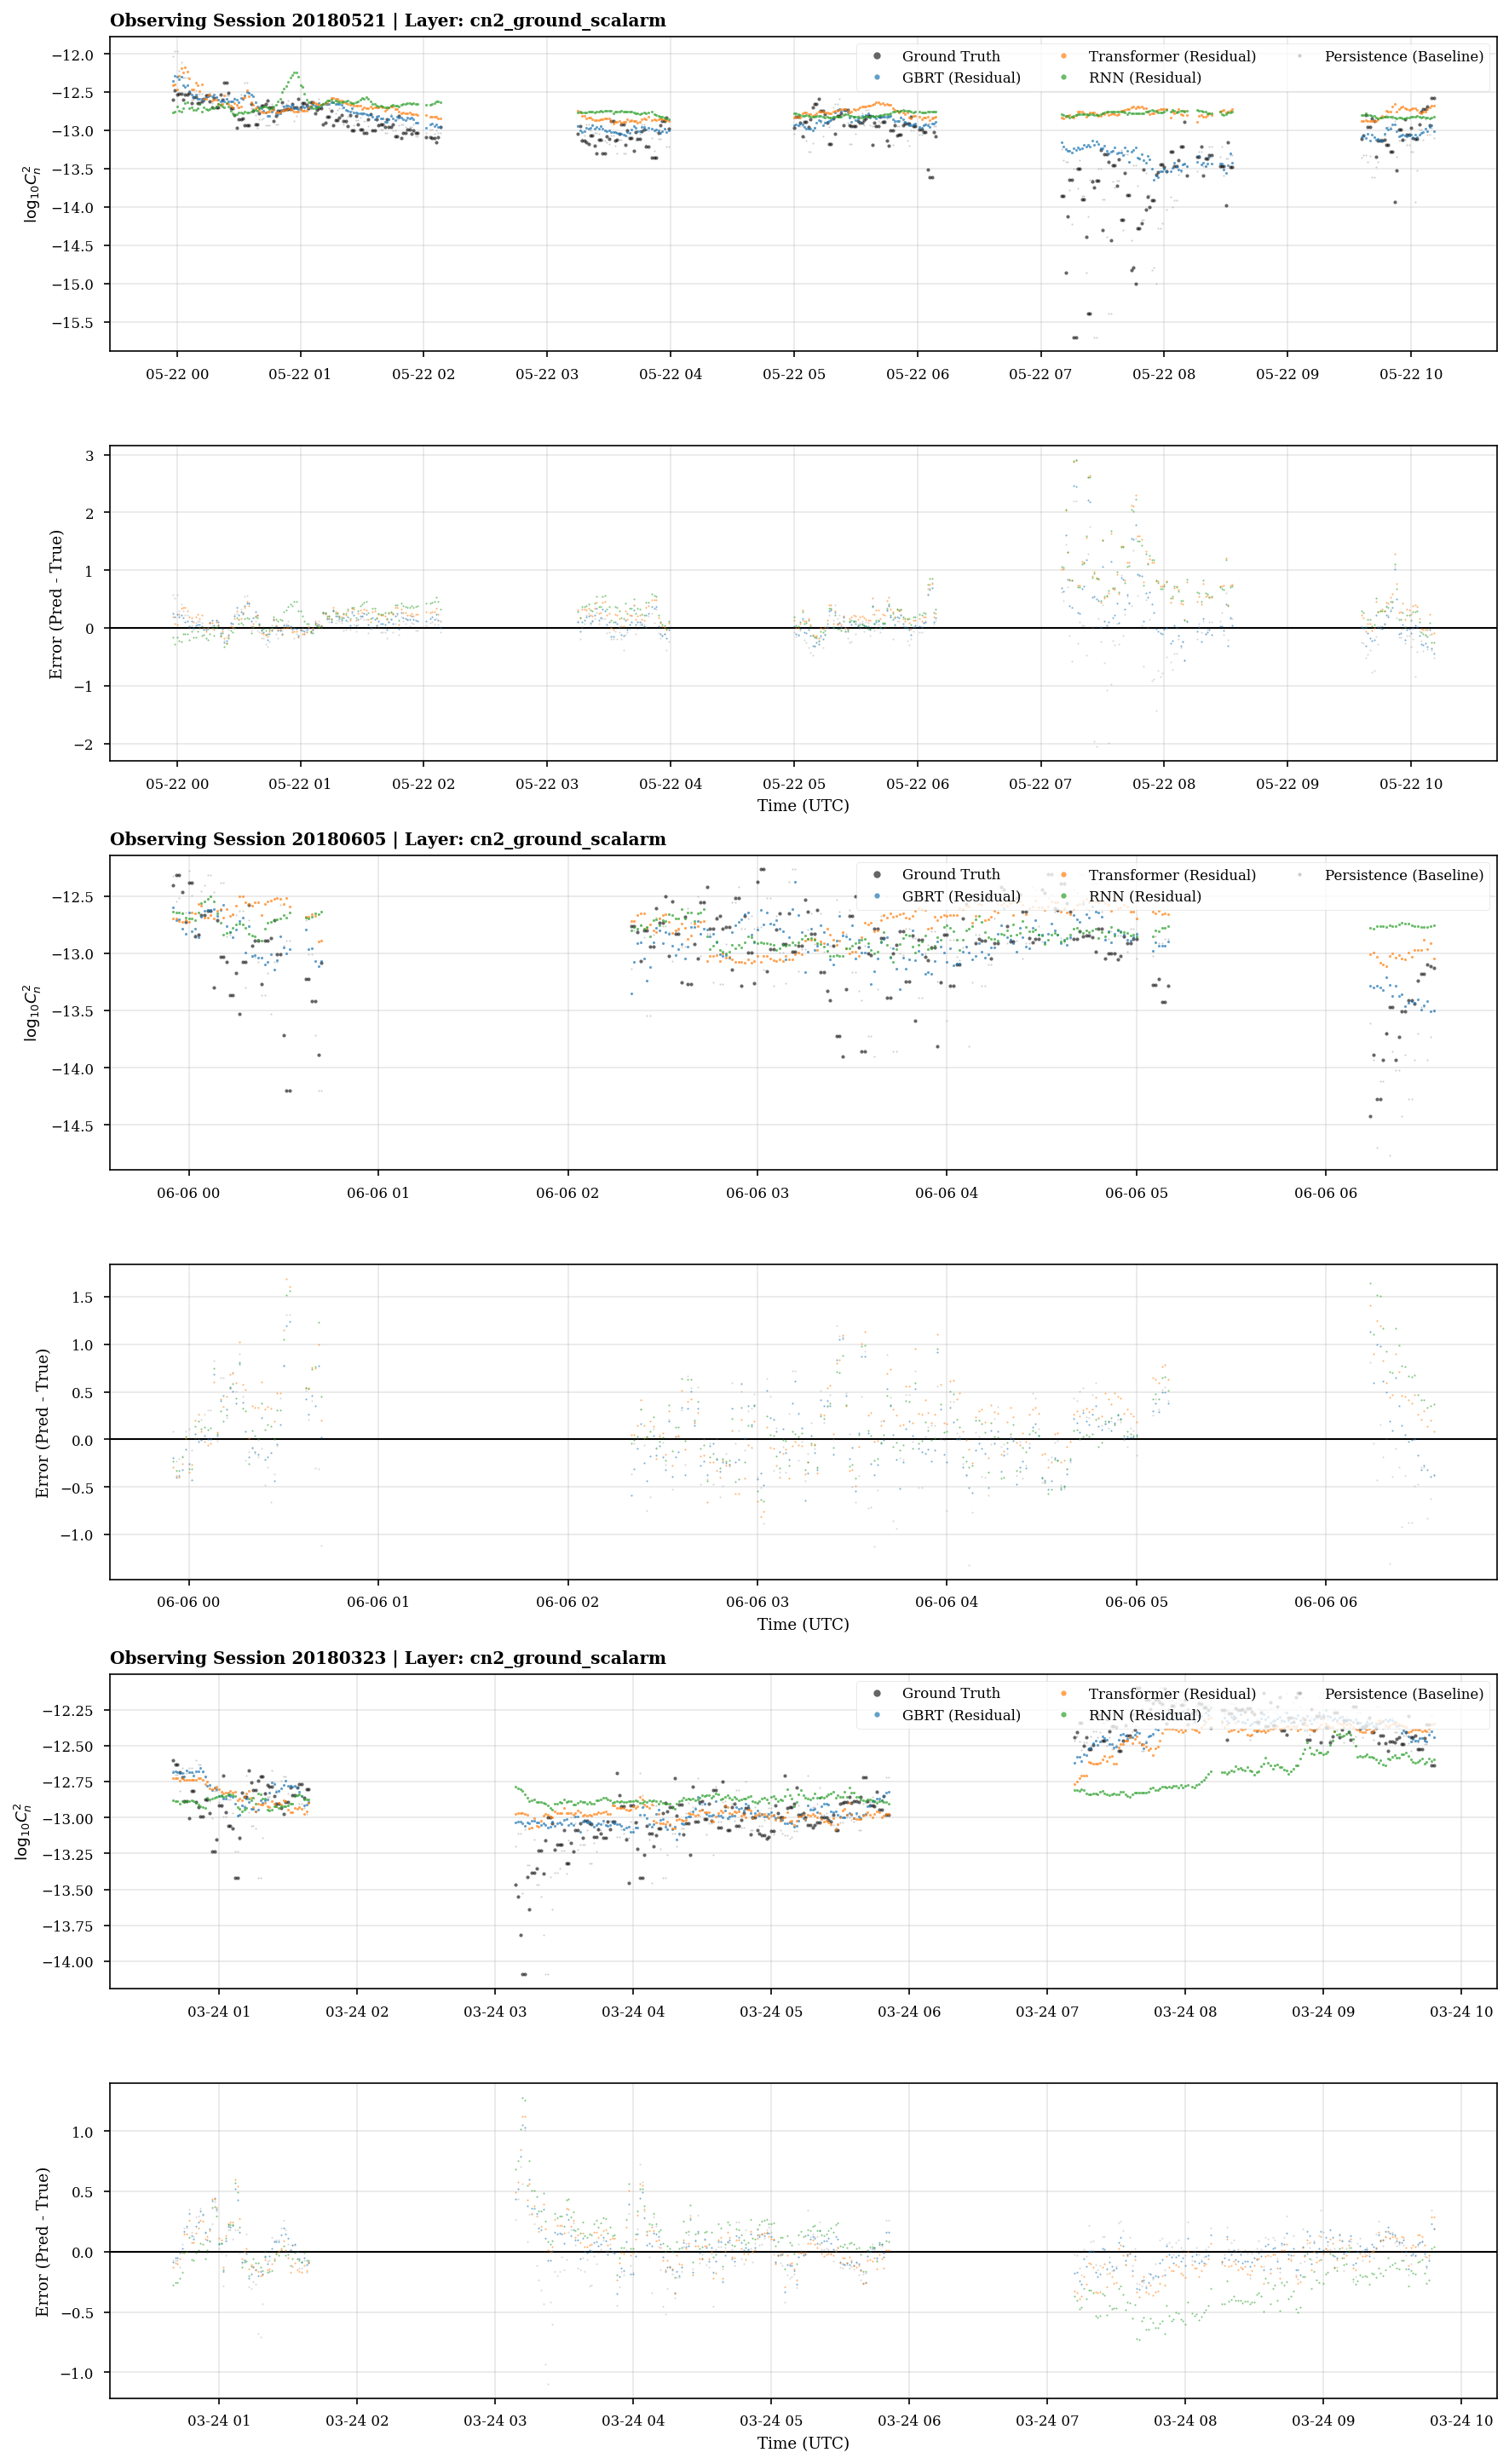

In [ ]:
viz.plot_nightly_comparison(
    models=["GBRT (Residual)", "Transformer (Residual)", "RNN (Residual)",  "Persistence (Baseline)"],
    layer_idx=0, # Ground Layer (0m)
    n_nights=3,
    plot_residuals=True
)

<AxesSubplot:title={'center':'Vertical Profile of Predictive Skill'}, xlabel='Skill Score ($1 - MSE_{model}/MSE_{pers}$)', ylabel='Altitude Layer'>

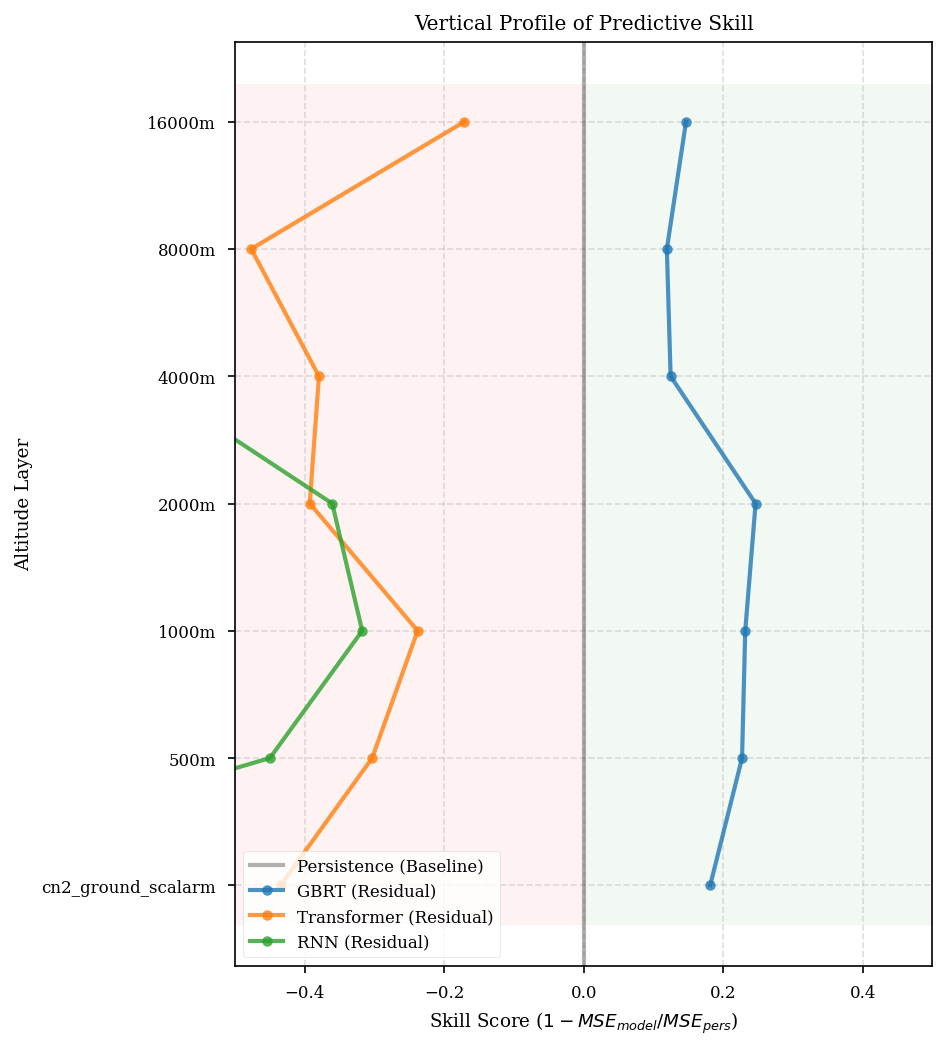

In [ ]:
viz.plot_skill_profile(
    models=["GBRT (Residual)", "Transformer (Residual)",  "RNN (Residual)", "Linear (Residual)"], 
)


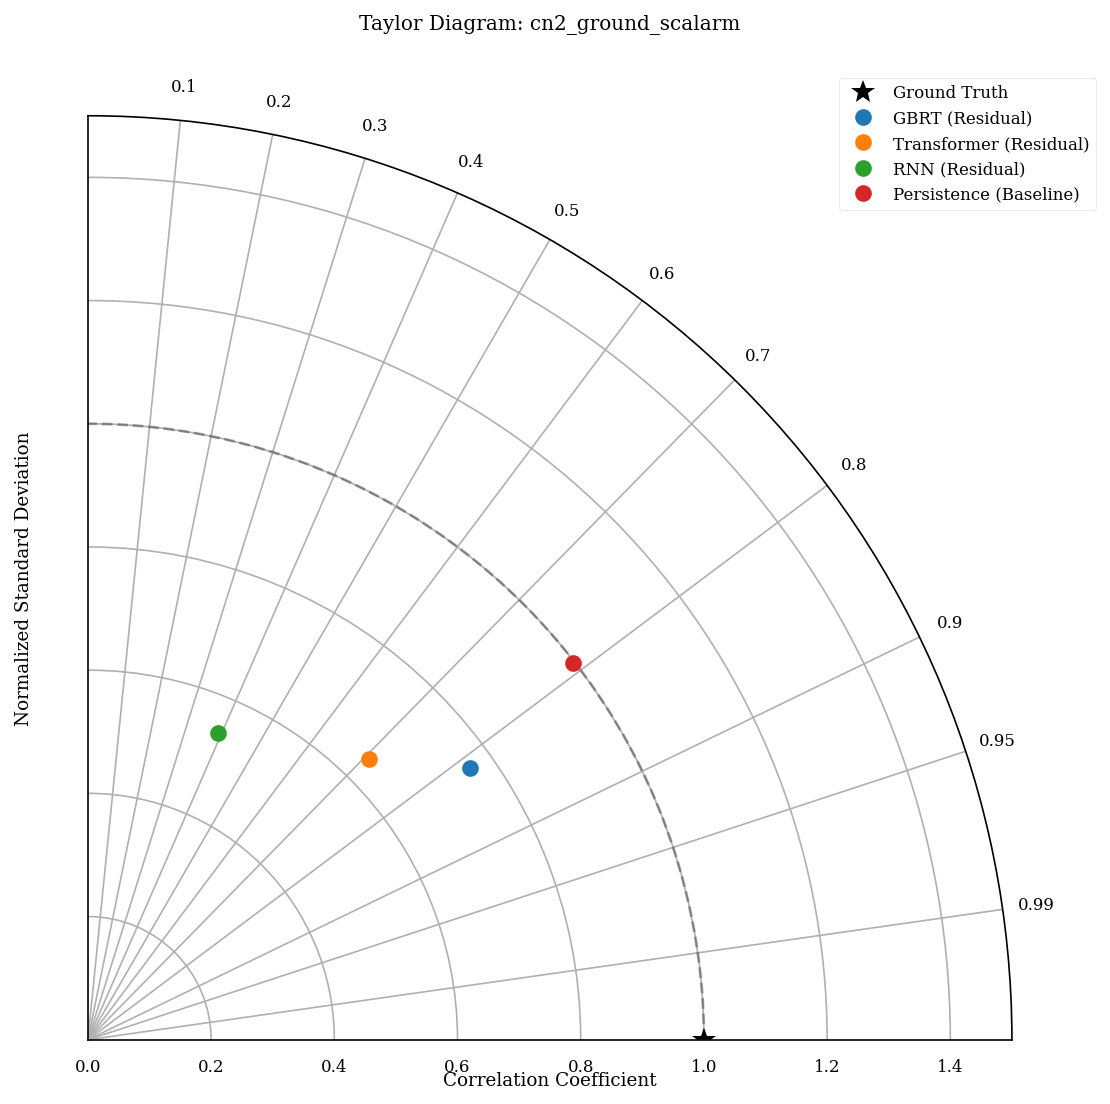

In [ ]:
# Cell 2: Taylor Diagram
# Visualize Correlation vs. Standard Deviation for the Ground Layer (Layer 0)
viz.plot_taylor_diagram(
    layer_idx=0, 
    models=["GBRT (Residual)", "Transformer (Residual)", "RNN (Residual)", "Persistence (Baseline)"]
)

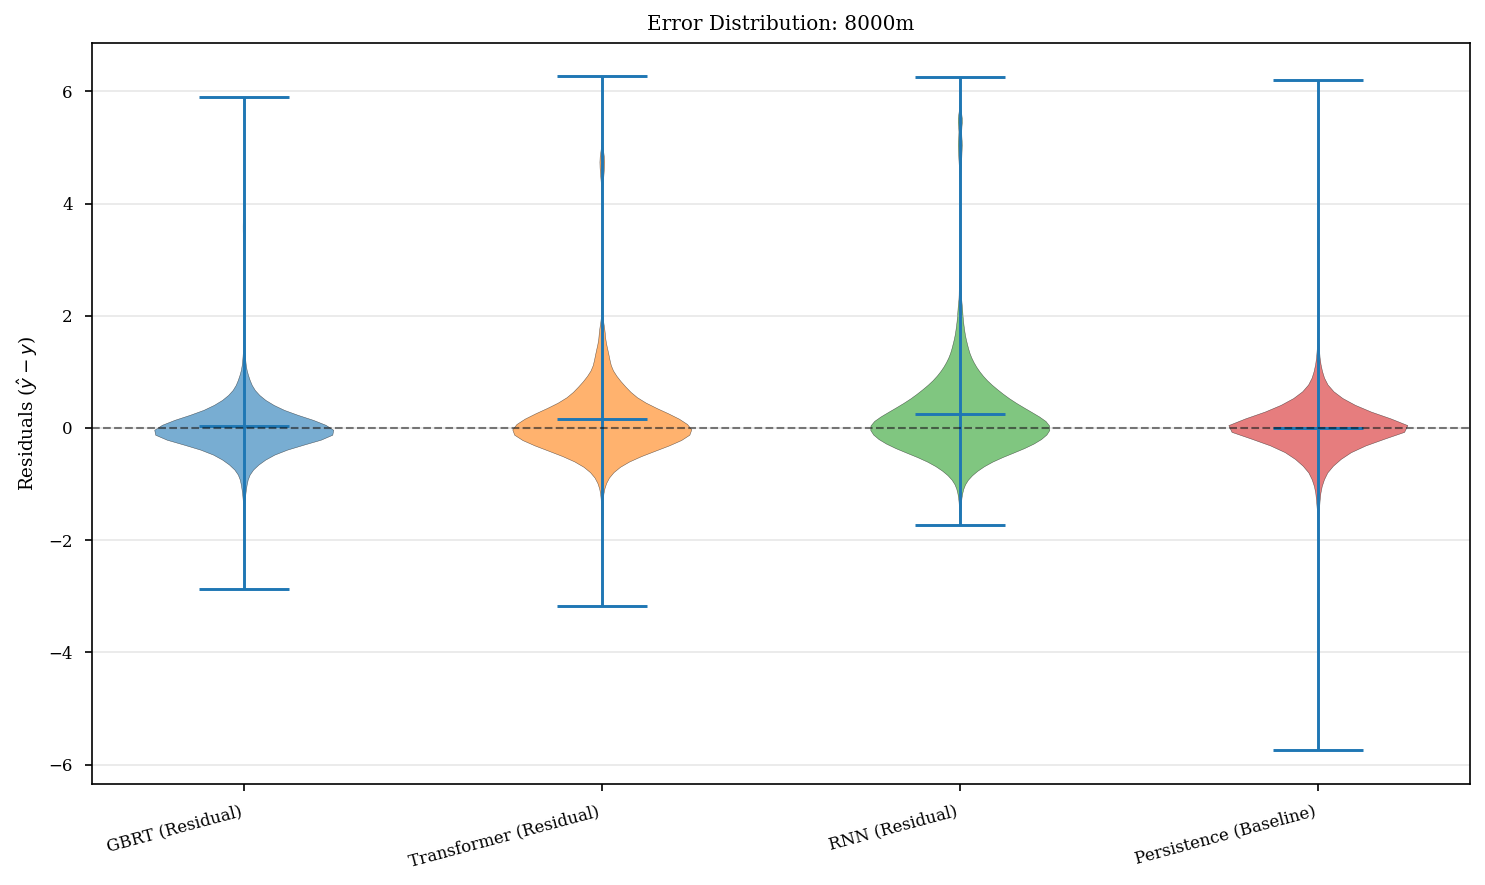

In [ ]:
# Cell 3: Error Distribution (Violin Plot)
# Compare the statistical stability of errors at the Jet Stream layer (Layer 5)
viz.plot_error_distribution(
    layer_idx=5, 
    models=["GBRT (Residual)", "Transformer (Residual)",  "RNN (Residual)", "Persistence (Baseline)"]
)

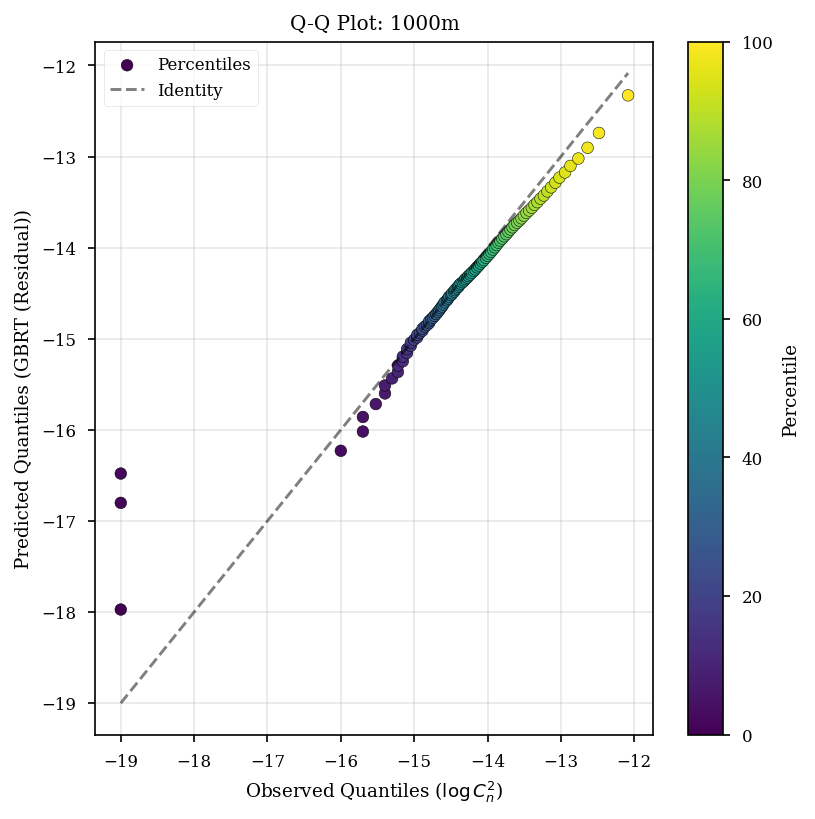

In [ ]:
# Cell 4: Q-Q Plot (Single Model Diagnostic)
# Check if GBRT captures the extreme tails of the distribution
viz.plot_qq(
    model_name="GBRT (Residual)", 
)

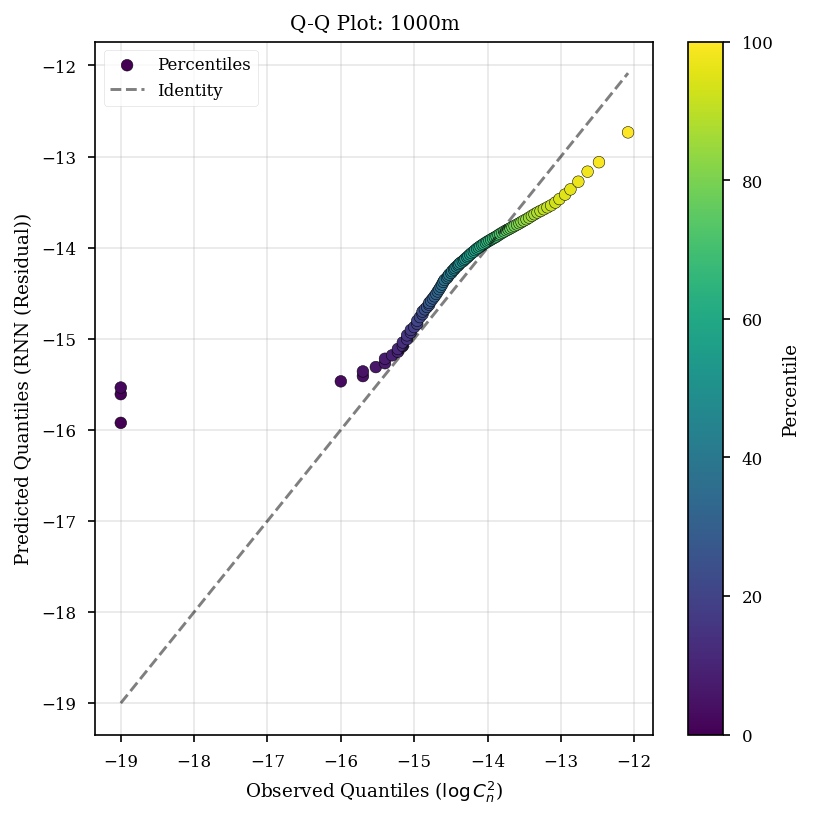

In [ ]:
# Cell 4: Q-Q Plot (Single Model Diagnostic)
# Check if GBRT captures the extreme tails of the distribution
viz.plot_qq(
    model_name="RNN (Residual)", 
)

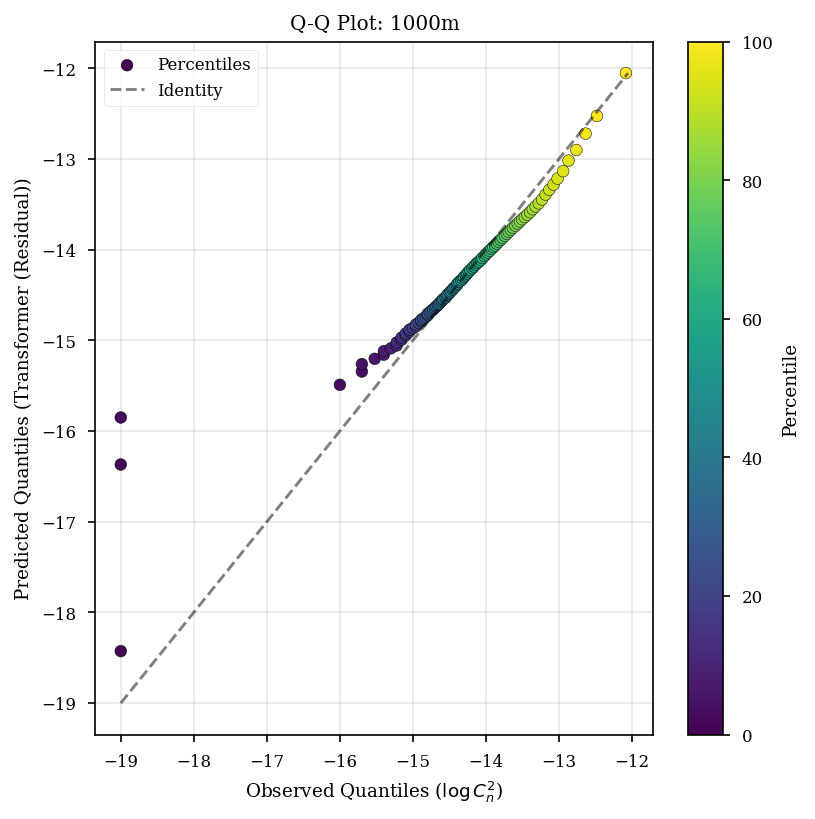

In [ ]:
# Cell 4: Q-Q Plot (Single Model Diagnostic)
# Check if GBRT captures the extreme tails of the distribution
viz.plot_qq(
    model_name="Transformer (Residual)", 
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


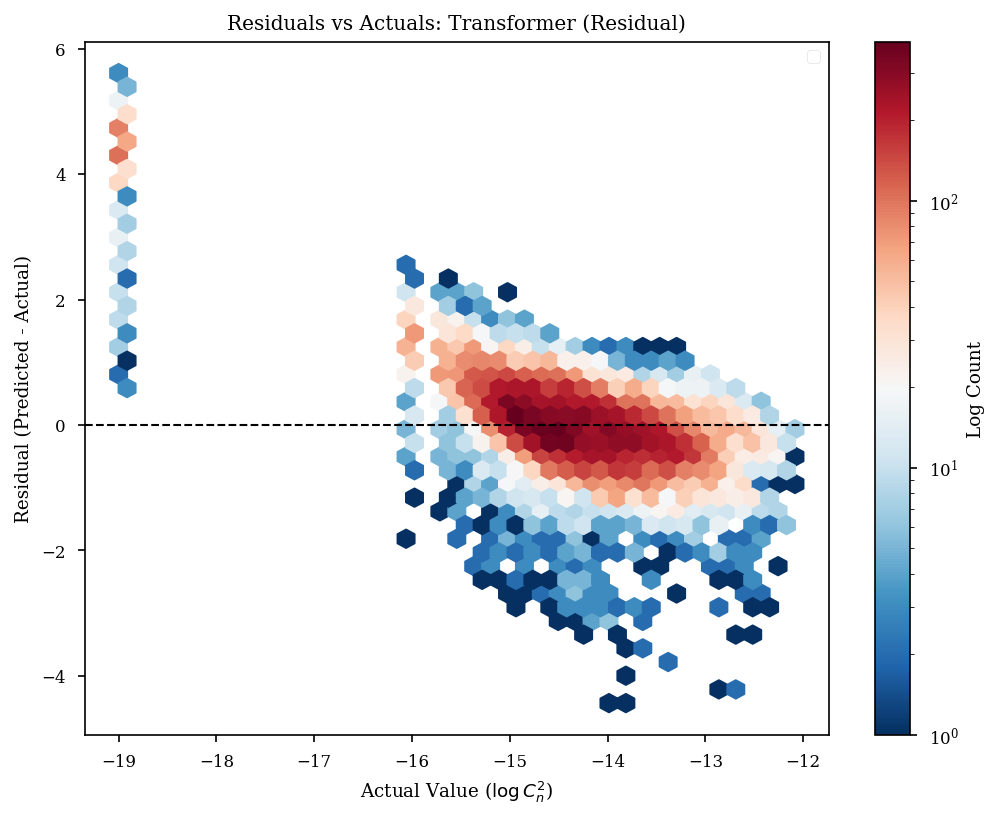

In [ ]:
# Cell 5: Residuals vs. Actuals
# Diagnose systematic bias in the Transformer model
viz.plot_residuals_vs_actuals(
    model_name="Transformer (Residual)",
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


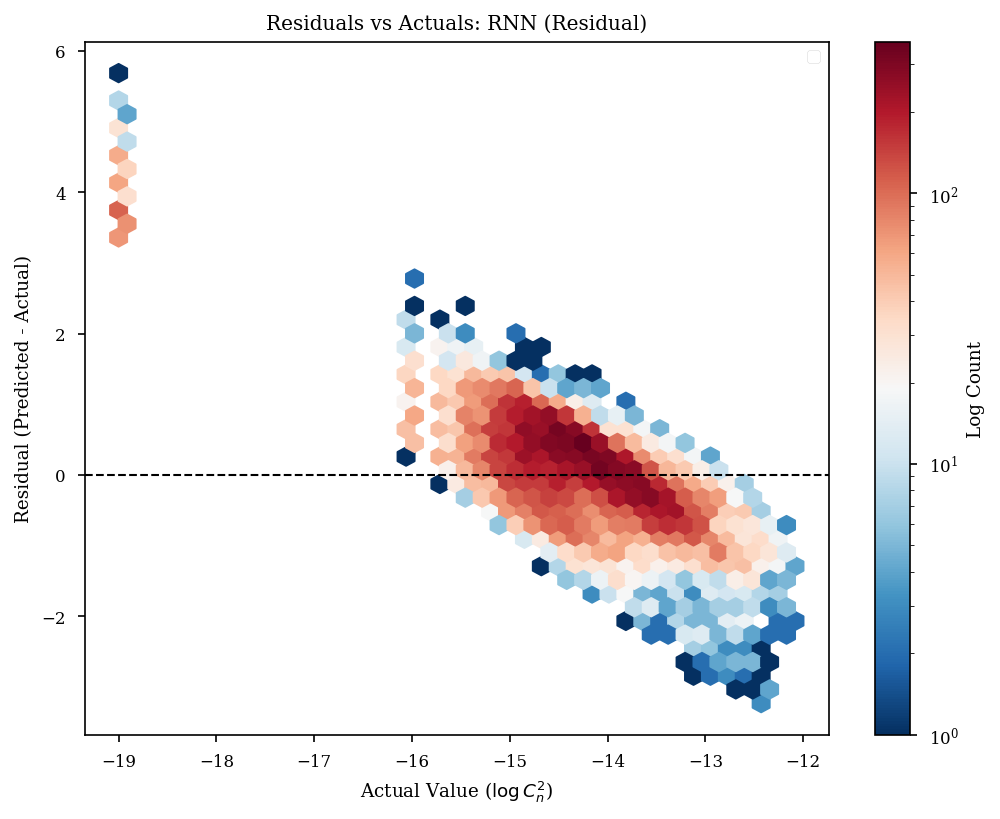

In [ ]:
# Cell 5: Residuals vs. Actuals
# Diagnose systematic bias in the Transformer model
viz.plot_residuals_vs_actuals(
    model_name="RNN (Residual)",
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


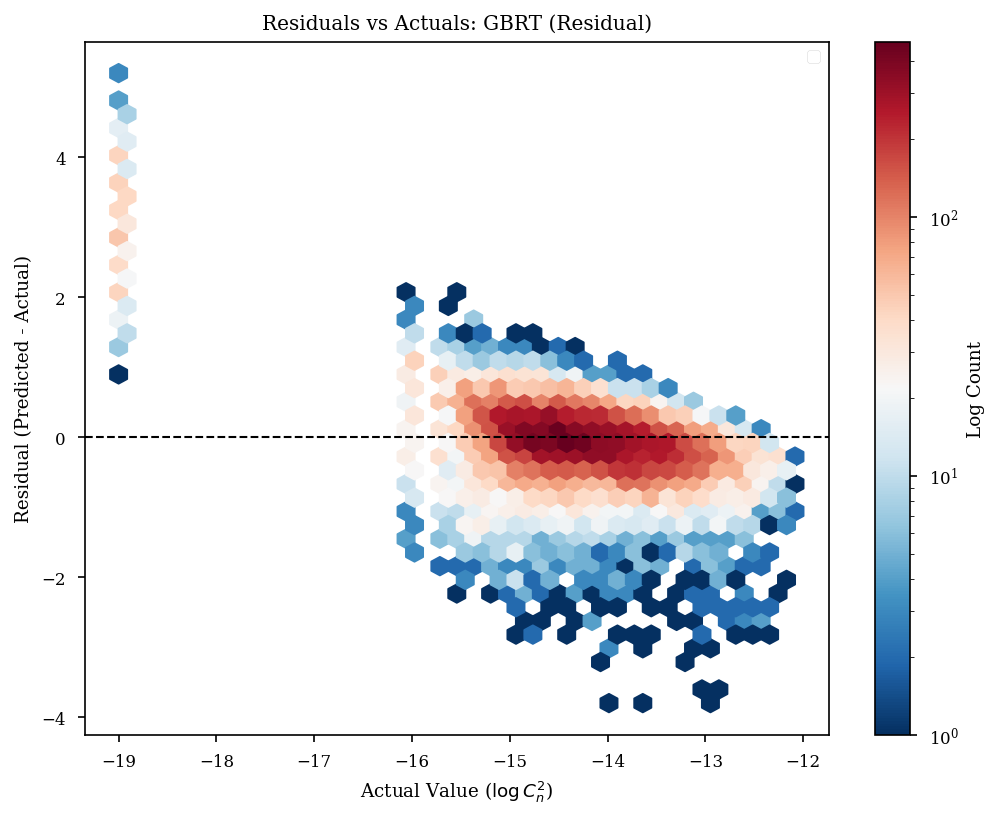

In [ ]:
# Cell 5: Residuals vs. Actuals
# Diagnose systematic bias in the Transformer model
viz.plot_residuals_vs_actuals(
    model_name="GBRT (Residual)",
)

/tmp/ipykernel_85226/1404297738.py:639: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_true_filled = pd.Series(y_true).interpolate().fillna(method='bfill').values
/tmp/ipykernel_85226/1404297738.py:640: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_pred_filled = pd.Series(y_pred).interpolate().fillna(method='bfill').values


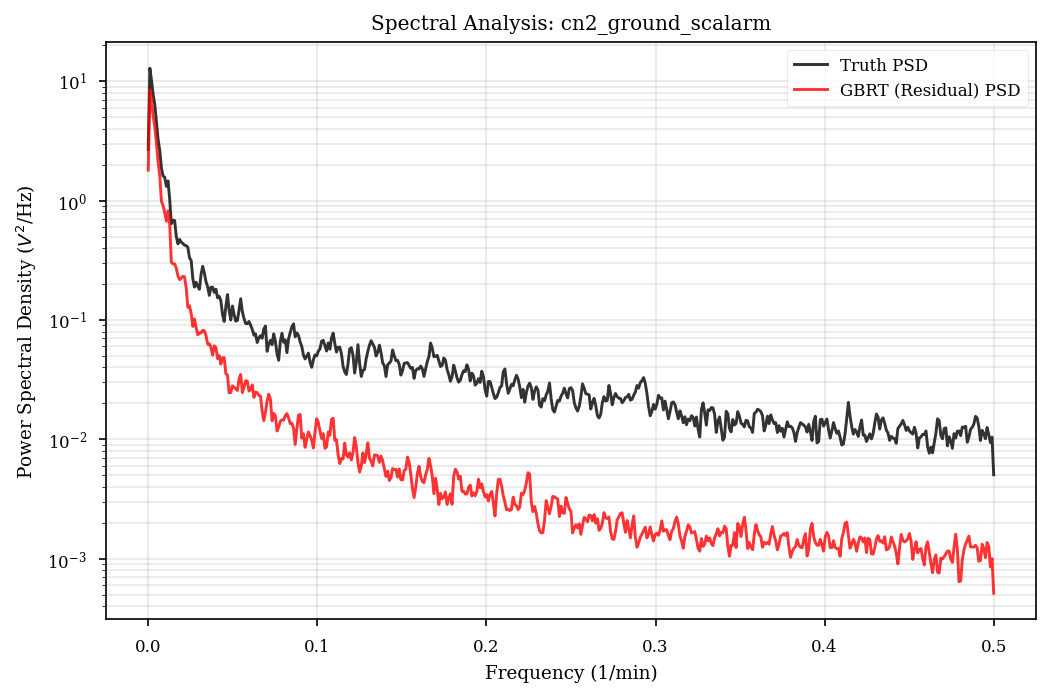

In [ ]:
# Cell 6: Spectral Analysis (PSD)
# Check for over-smoothing in the GBRT predictions
viz.plot_psd(
    model_name="GBRT (Residual)", 
    layer_idx=0
)

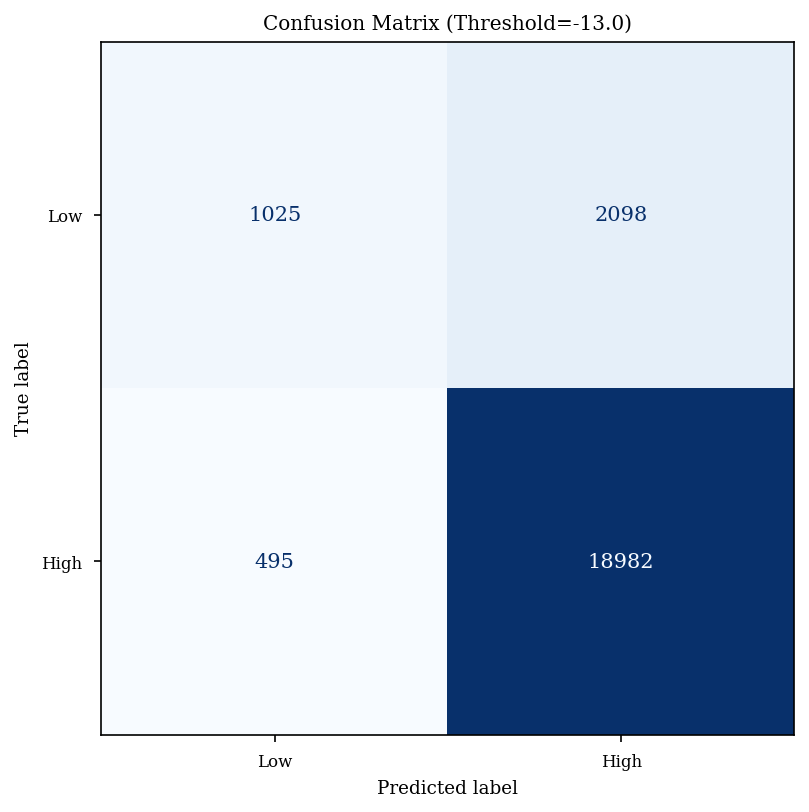

In [ ]:
# Cell 7: Operational Confusion Matrix
# Test accuracy for detecting "Bad Seeing" events (> -13.0 log Cn2)
viz.plot_confusion_matrix(
    model_name="GBRT (Residual)", 
    layer_idx=0, 
    threshold=-13.0 # Physically relevant threshold for "High Turbulence"
)

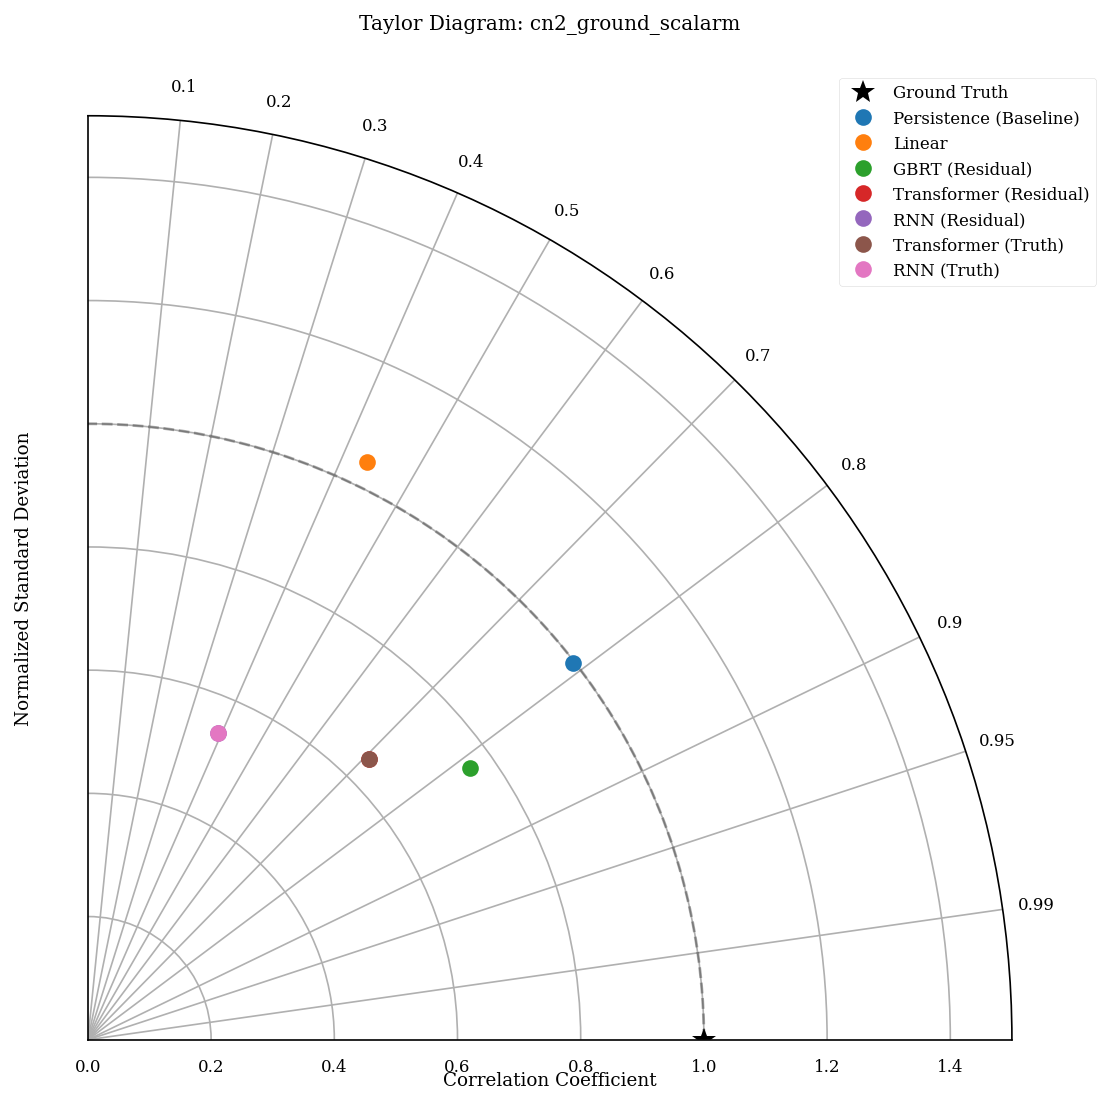

In [ ]:
# 1. Physics Check: Taylor Diagram
# Look for models closest to the Black Star.
# Models near the origin are "dead" (predicting mean).
viz.plot_taylor_diagram(layer_idx=0)

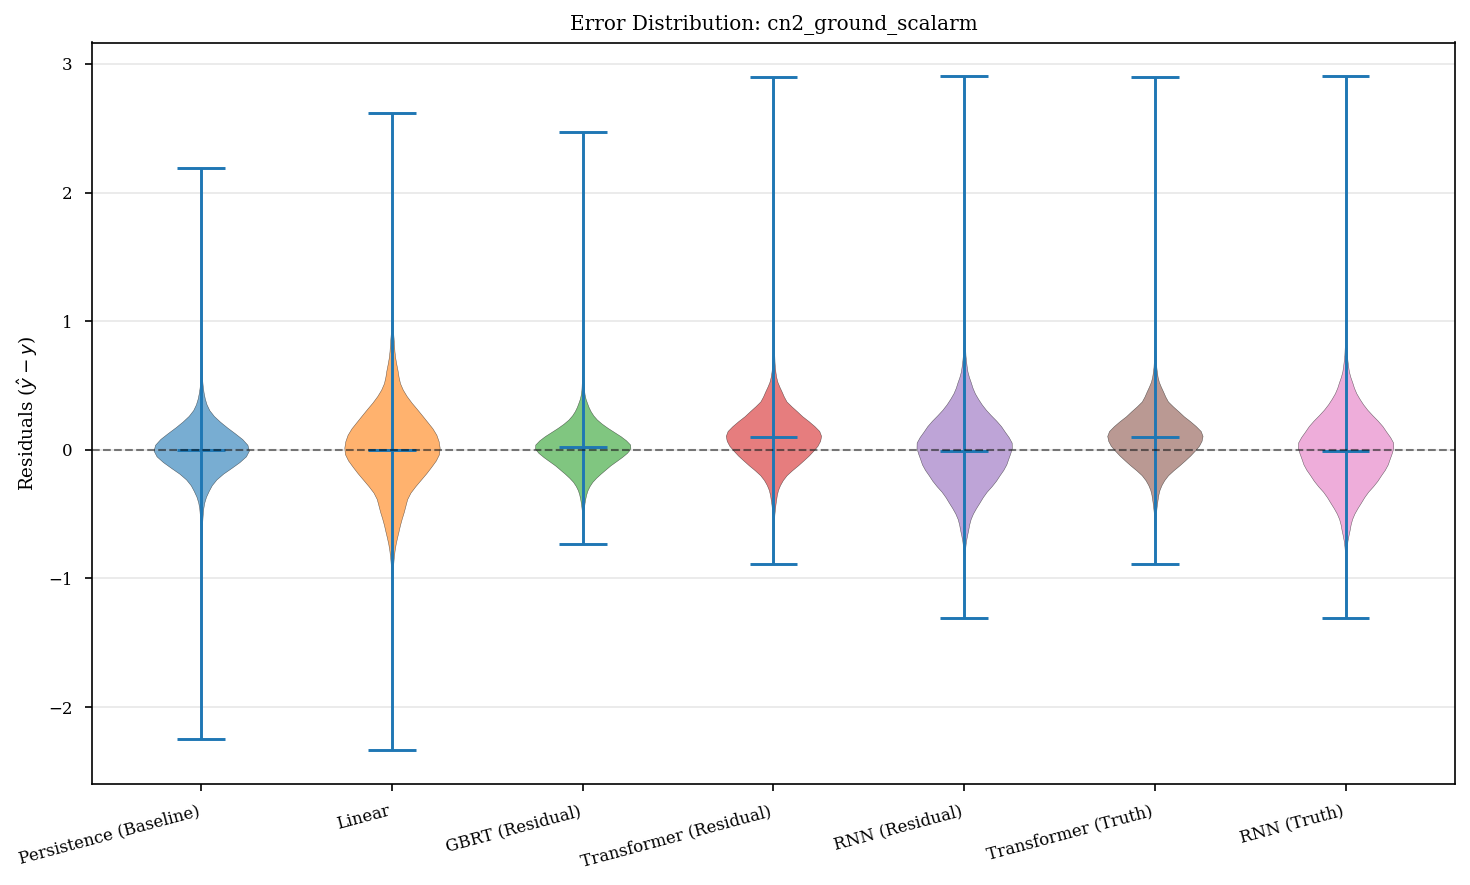

In [ ]:
# 2. Stability Check: Violin Plot
# Look for the "flattest" violin centered on 0.
# Long tails indicate risk.
viz.plot_error_distribution(layer_idx=0)

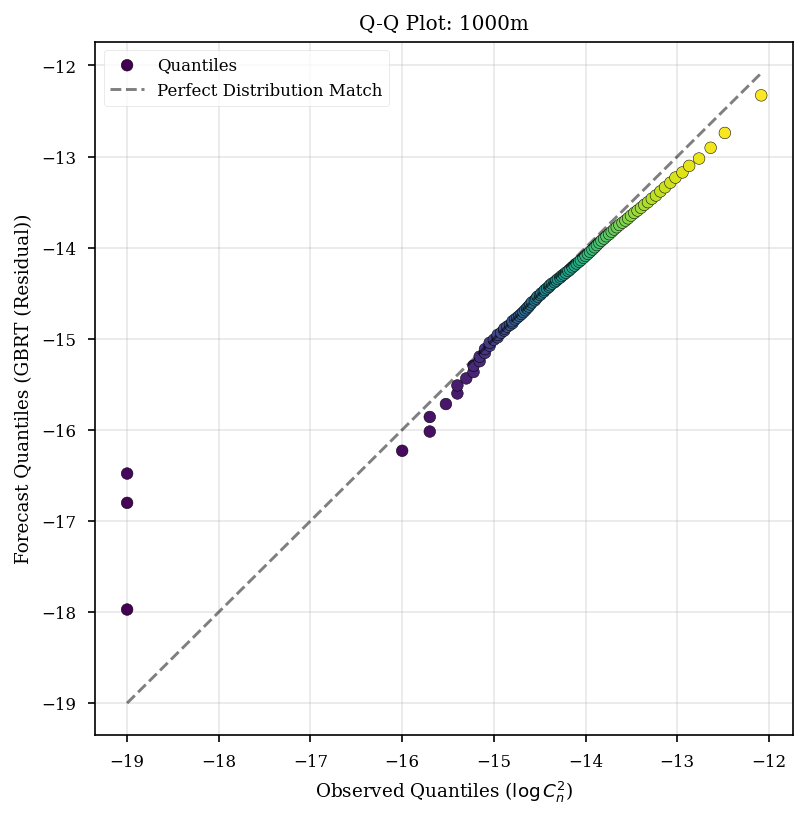

In [ ]:
viz.plot_qq_comparison(
    model_name="GBRT (Residual)"
)

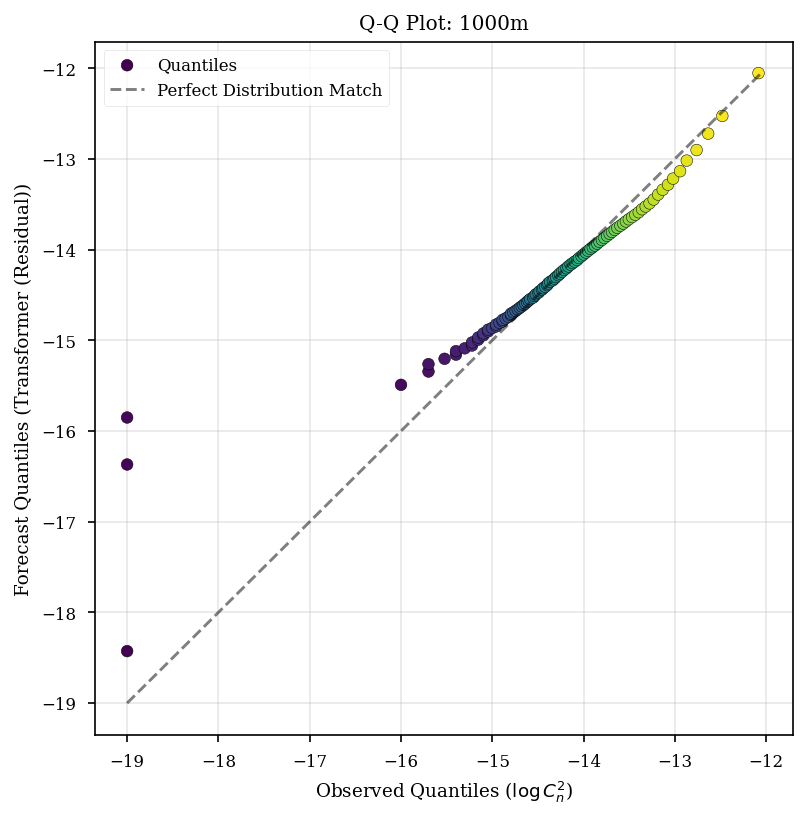

In [ ]:
viz.plot_qq_comparison(
    model_name="Transformer (Residual)"
)

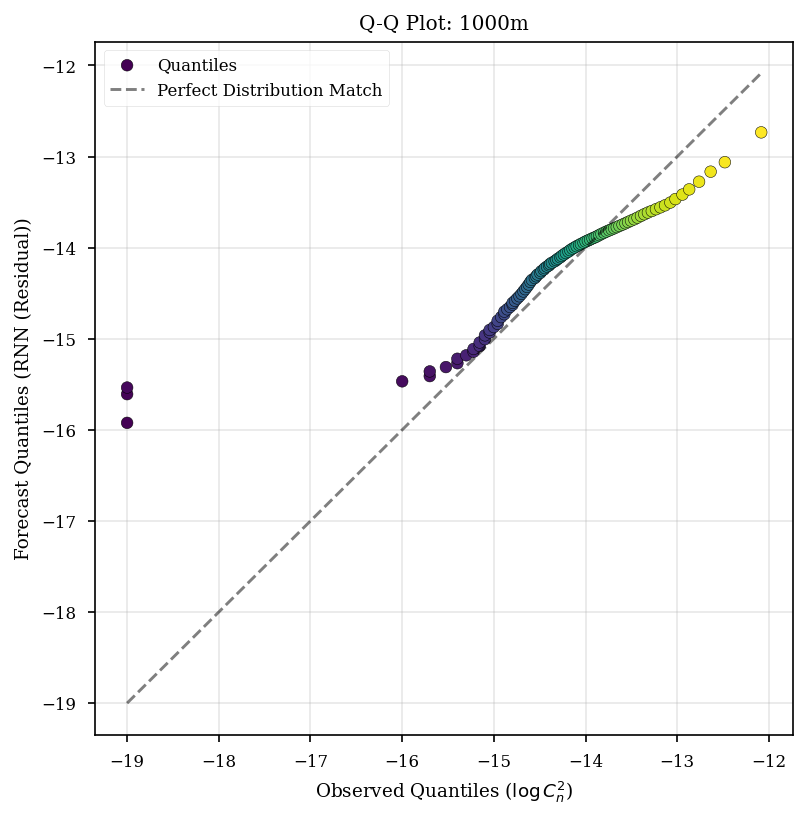

In [ ]:
viz.plot_qq_comparison(
    model_name="RNN (Residual)"
)

<AxesSubplot:title={'center':'Vertical Profile of Predictive Skill'}, xlabel='Skill Score ($1 - MSE_{model}/MSE_{pers}$)', ylabel='Altitude Layer'>

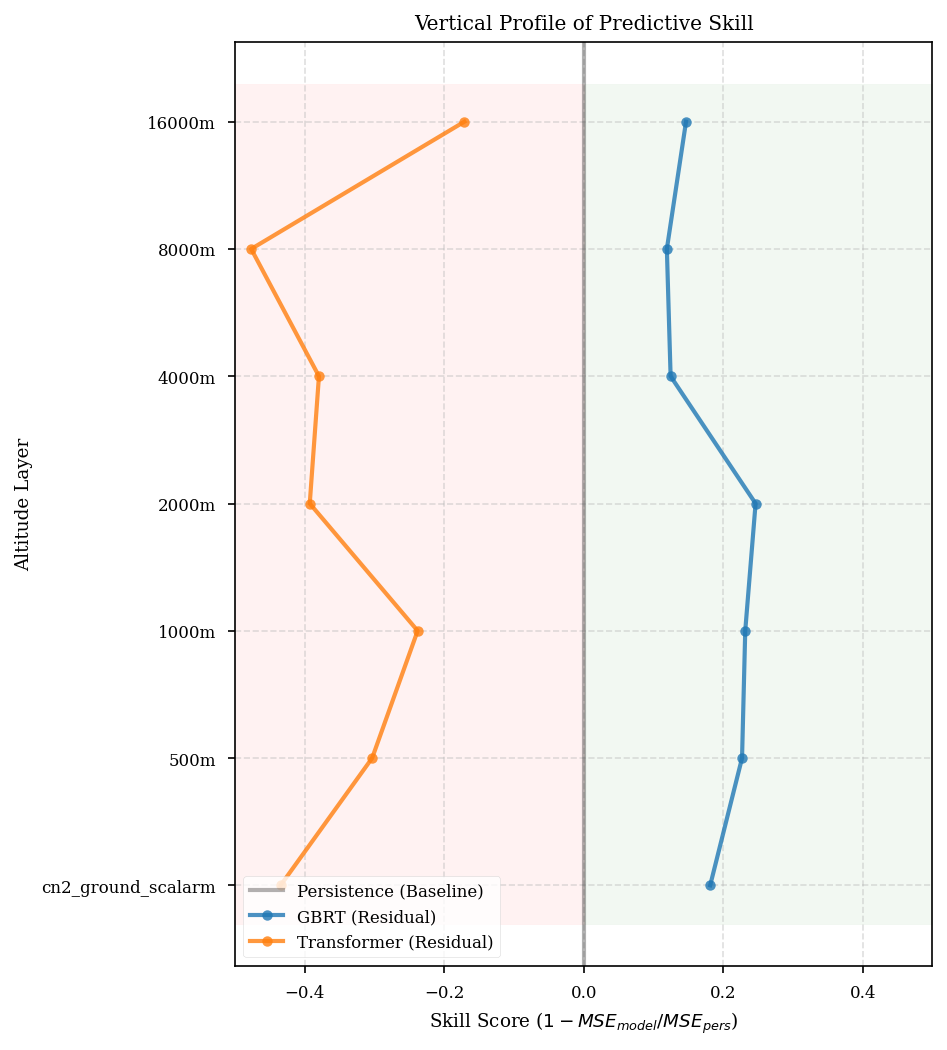

In [ ]:
viz.plot_skill_profile(
    models=["GBRT (Residual)", "Transformer (Residual)", "Persistence (Baseline)"], 
)


# dep

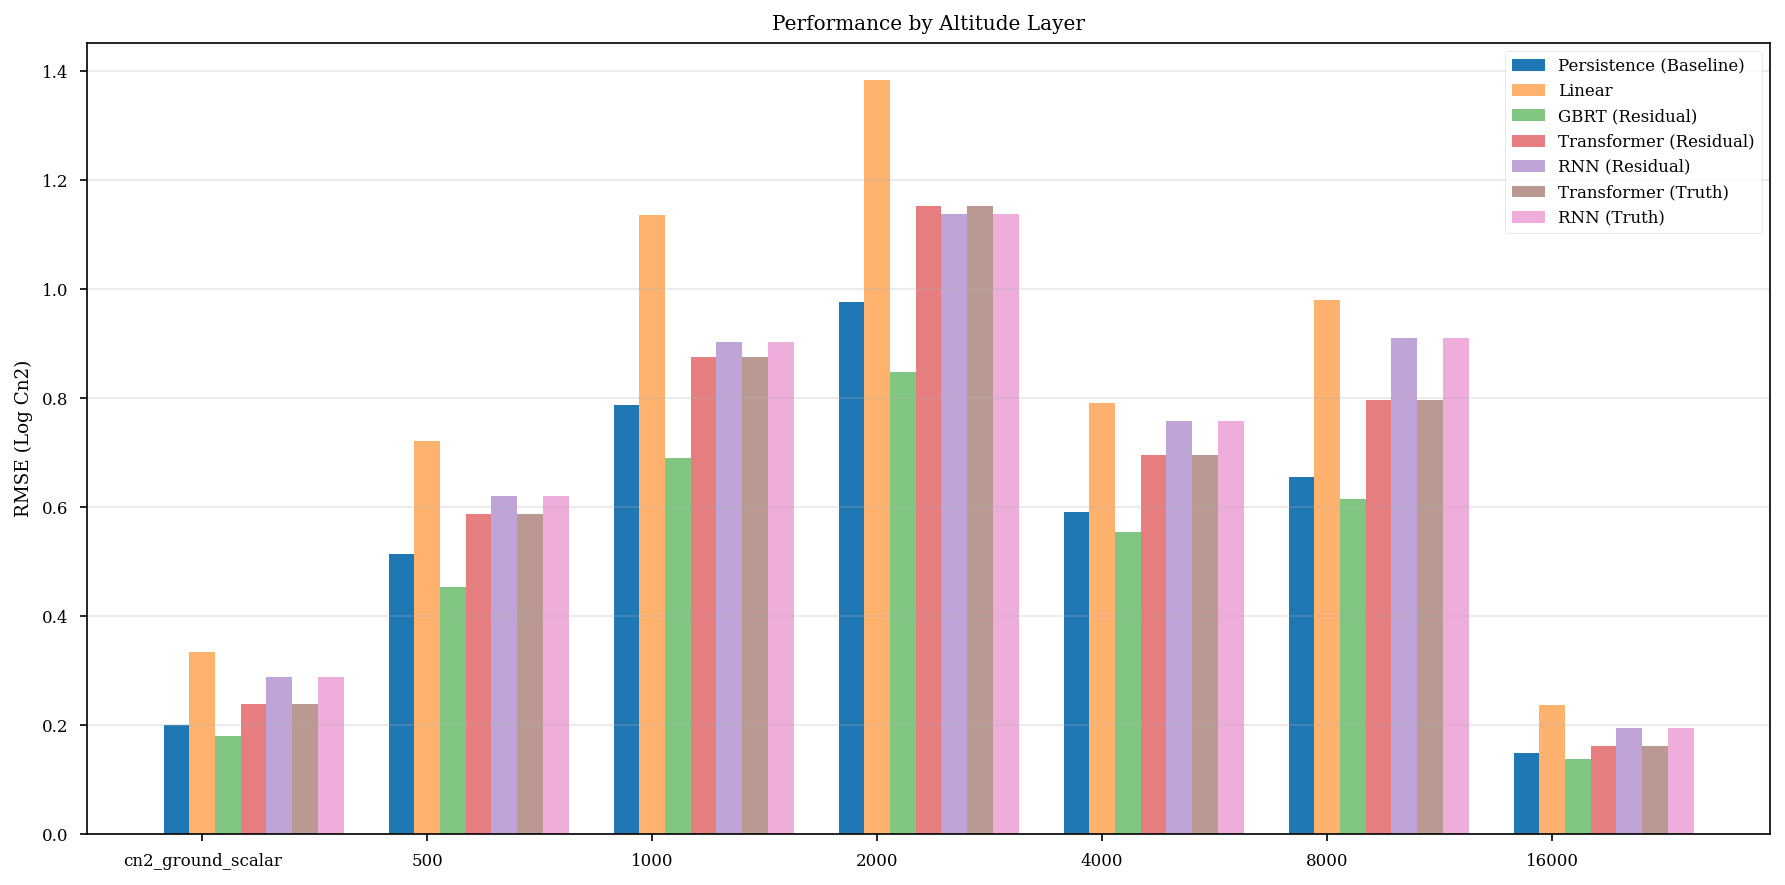

In [ ]:
def plot_layer_performance(runner, y_test):
    """
    Compares RMSE per altitude layer across all models.
    """
    layer_names = [c.replace('cn2_free_atmos_', '') for c in y_test.columns]
    n_layers = len(layer_names)
    
    # Calculate per-layer RMSE for each model
    model_rmse = {}
    for name, y_pred in runner.predictions.items():
        # y_test is DataFrame, y_pred is Numpy
        mse = np.mean((y_test.values - y_pred)**2, axis=0)
        model_rmse[name] = np.sqrt(mse)
        
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(n_layers)
    width = 0.8 / len(model_rmse)
    
    for i, (name, rmse) in enumerate(model_rmse.items()):
        offset = width * i
        # Highlight best model vs baseline
        alpha = 1.0 if "GradientBoosting" in name or "Persistence" in name else 0.6
        rects = ax.bar(x + offset, rmse, width, label=name, alpha=alpha)
        
    ax.set_ylabel('RMSE (Log Cn2)')
    ax.set_title('Performance by Altitude Layer')
    ax.set_xticks(x + width, layer_names)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run it
plot_layer_performance(runner, y_test)

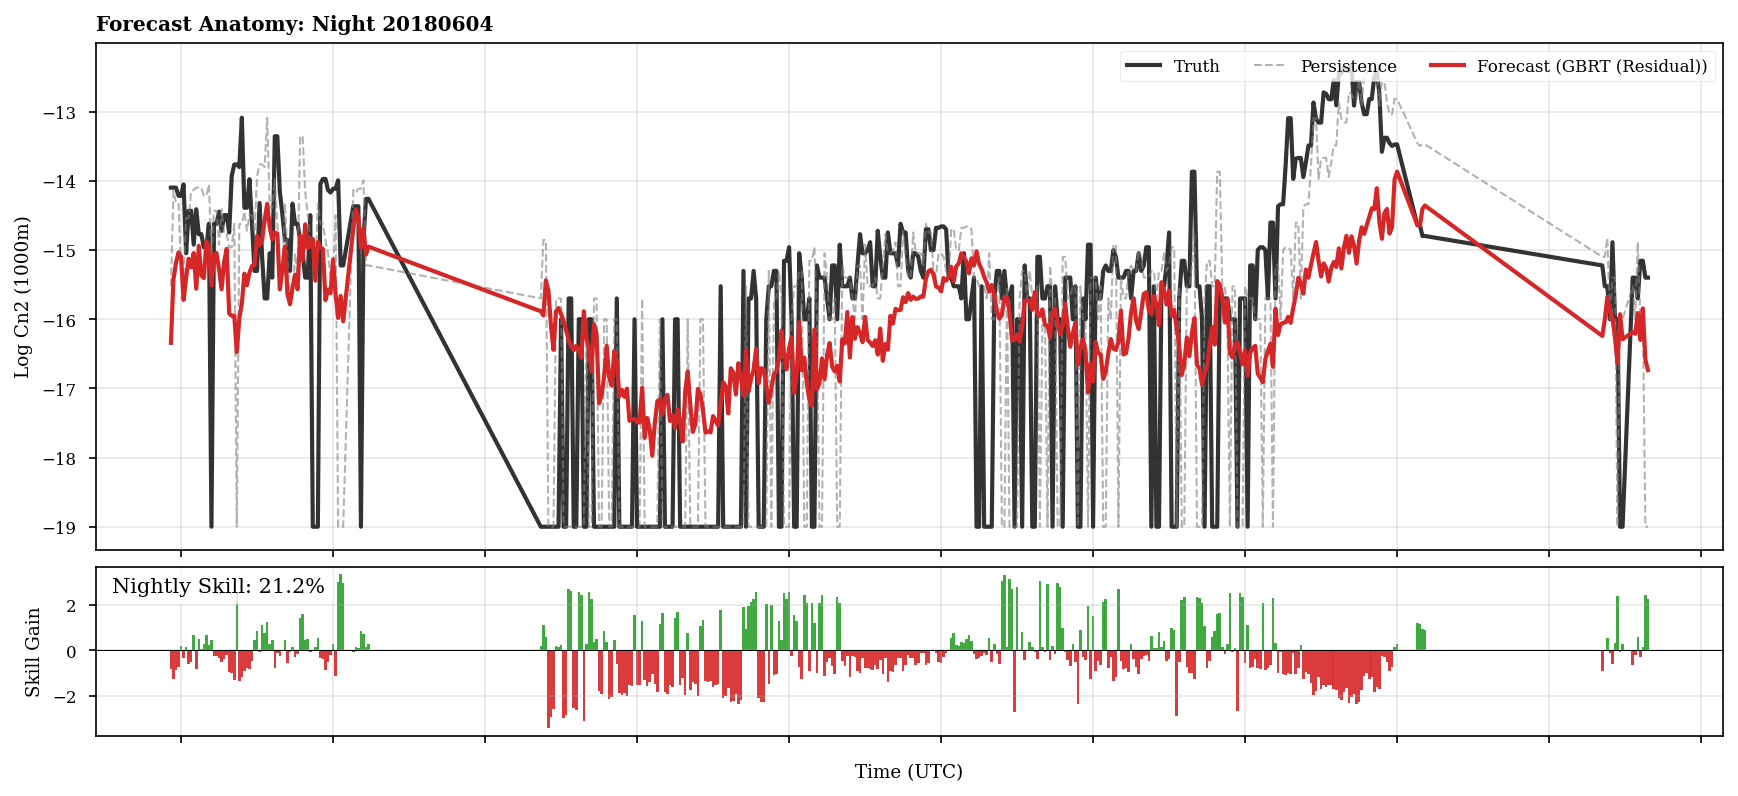

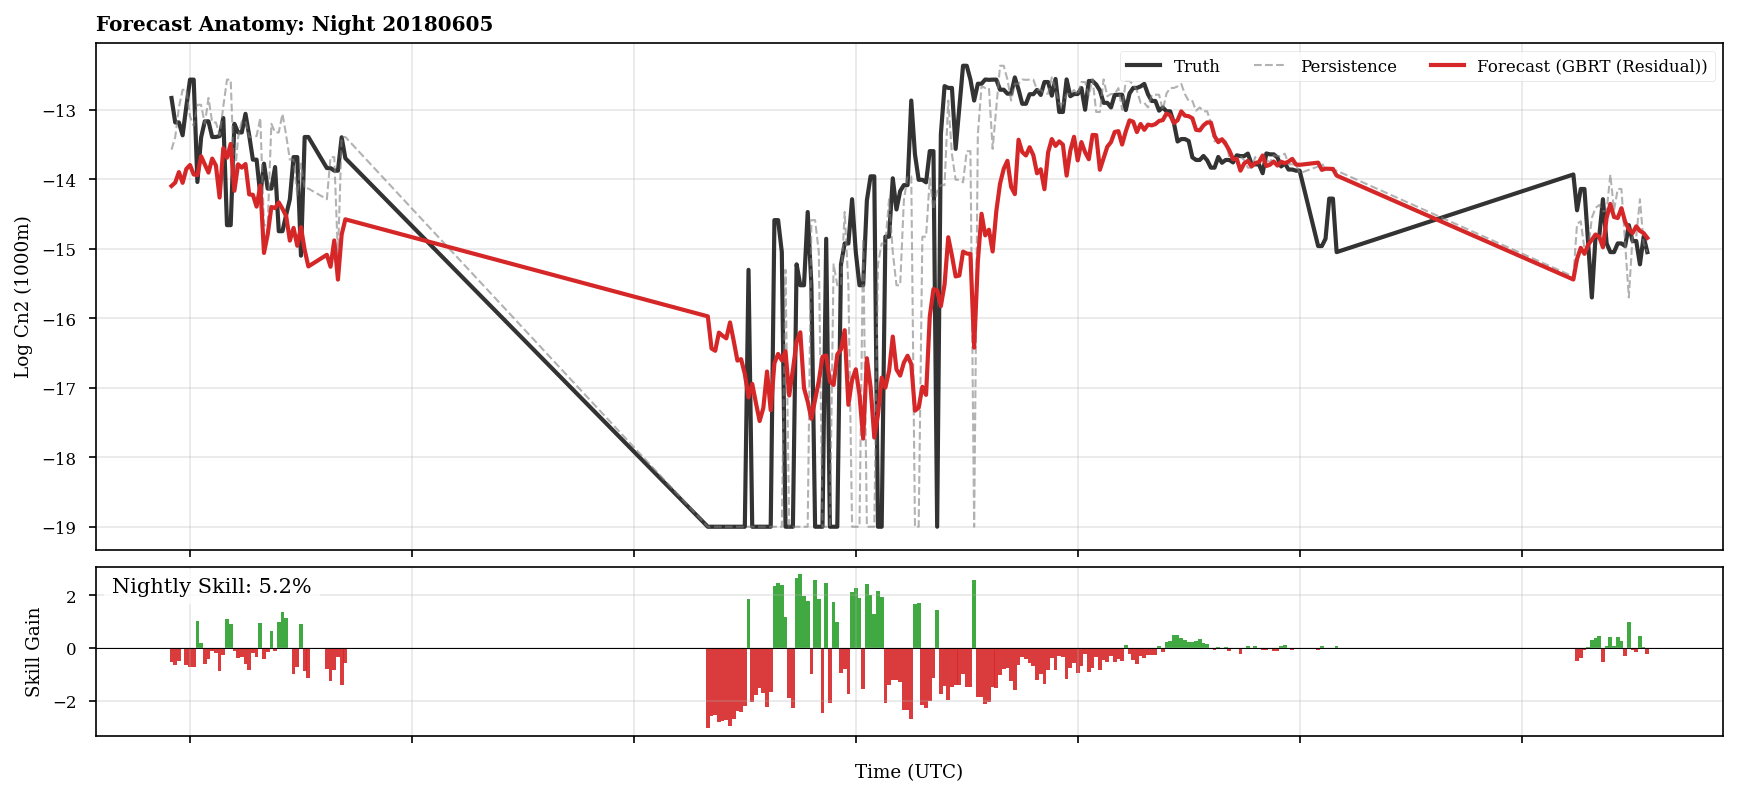

In [ ]:
def visualize_forecast_anatomy(runner, X_test, y_test, layer_idx=2, num_nights=2):
    """
    Generates a rigorous Night-by-Night view of model performance.
    """
    # 1. Recover Metadata (Night IDs)
    ds_full = task.get_dataset()
    # Safe context recovery using the index
    context = ds_full.get_context(X_test.index, columns=["night_id"])
    
    # 2. Build Analysis DataFrame
    df_viz = pd.DataFrame(index=X_test.index)
    df_viz["night_id"] = context["night_id"].values
    df_viz["Truth"] = y_test.iloc[:, layer_idx].values
    
    # Add predictions
    for name, pred in runner.predictions.items():
        df_viz[name] = pred[:, layer_idx]
        
    # 3. Select Interesting Nights (High Variance = "Storms")
    top_nights = df_viz.groupby("night_id")["Truth"].std().sort_values(ascending=False).head(num_nights).index
    
    # 4. Plot
    layer_name = y_test.columns[layer_idx].replace("cn2_free_atmos_", "") + "m"
    
    for night in top_nights:
        night_data = df_viz[df_viz["night_id"] == night]
        
        fig = plt.figure(figsize=(14, 6))
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
        
        # Upper Panel: Trajectories
        ax0 = fig.add_subplot(gs[0])
        ax0.plot(night_data.index, night_data["Truth"], 'k-', lw=2, label="Truth", alpha=0.8)
        
        # Plot Persistence (Baseline)
        if "Persistence (Baseline)" in night_data.columns:
            ax0.plot(night_data.index, night_data["Persistence (Baseline)"], 
                     color='gray', ls='--', lw=1, alpha=0.6, label="Persistence")
            
        # Plot Best Model (e.g. GBRT)
        # Find best non-baseline model
        best_model = leaderboard.index[0]
        if best_model in night_data.columns:
            ax0.plot(night_data.index, night_data[best_model], 
                     color='#d62728', lw=2, label=f"Forecast ({best_model})")
            
        ax0.set_ylabel(f"Log Cn2 ({layer_name})")
        ax0.set_title(f"Forecast Anatomy: Night {night}", loc='left', fontweight='bold')
        ax0.legend(loc='upper right', ncol=3)
        ax0.grid(True, alpha=0.3)
        ax0.set_xticklabels([])
        
        # Lower Panel: Skill Advantage
        ax1 = fig.add_subplot(gs[1], sharex=ax0)
        
        # Advantage = |Err_Pers| - |Err_Model|
        err_pers = np.abs(night_data["Truth"] - night_data["Persistence (Baseline)"])
        err_model = np.abs(night_data["Truth"] - night_data[best_model])
        advantage = err_pers - err_model
        
        # Color logic: Green if Model wins, Red if Persistence wins
        colors = np.where(advantage > 0, '#2ca02c', '#d62728')
        
        ax1.bar(night_data.index, advantage, color=colors, width=0.0007, alpha=0.9)
        ax1.axhline(0, color='k', lw=0.5)
        ax1.set_ylabel("Skill Gain")
        ax1.set_xlabel("Time (UTC)")
        ax1.grid(True, alpha=0.3)
        
        # Annotate Net Skill for this night
        net_skill = 1 - (np.mean(err_model**2) / np.mean(err_pers**2))
        ax1.text(0.01, 0.85, f"Nightly Skill: {net_skill:.1%}", transform=ax1.transAxes,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        plt.show()

# Run Viz
visualize_forecast_anatomy(runner, X_test, y_test, layer_idx=2)